# BAGIAN 1 : Import Dataset

In [154]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn imbalanced-learn flask

# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

`!pip install`: Perintah ini menggunakan manajer paket Python (pip) untuk menginstal atau memverifikasi instalasi berbagai pustaka (libraries). Pustaka yang dipilih mengindikasikan tujuan proyek:

`xgboost`: Untuk membangun model klasifikasi Gradient Boosting.

`scikit-learn`: Pustaka utama untuk machine learning, digunakan untuk pemisahan data (train_test_split), tuning (RandomizedSearchCV), scaling (MinMaxScaler), dan metrik evaluasi.

`pandas, numpy`: Untuk manipulasi dan analisis data.

`matplotlib, seaborn`: Untuk visualisasi data.

`imbalanced-learn`: Pustaka khusus untuk menangani dataset yang tidak seimbang (yang akan relevan nanti).

`flask`: Pustaka web, menunjukkan kemungkinan niat untuk mendeploy model ini sebagai API (meskipun tidak digunakan lebih lanjut di notebook ini).

`import ...`: Mengimpor pustaka yang diperlukan ke dalam script.


**Akuisisi Data**

In [155]:
#Clone repository dari github untuk mengakses dataset yang telah diunggah di github sebelumnya
!git clone https://github.com/Andishafira/Dicoding.git

fatal: destination path 'Dicoding' already exists and is not an empty directory.


**Pemuatan Data (Data Loading)**

In [156]:
import pandas as pd

data_hr = pd.read_csv("/content/Dicoding/Belajar Penerapan Data Science/Tugas 1_Menyelesaikan Permasalahan Human Resources/employee_data.csv", sep=",")
data_hr.head(100)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,29,NaN,Travel_Rarely,136,Research & Development,1,3,Life Sciences,1,...,1,80,1,6,5,2,5,3,0,2
96,97,57,0.0,Travel_Rarely,405,Research & Development,1,2,Life Sciences,1,...,1,80,1,13,2,2,12,9,2,8
97,98,53,NaN,Travel_Rarely,1168,Sales,24,4,Life Sciences,1,...,2,80,0,15,2,2,2,2,2,2
98,99,33,0.0,Travel_Rarely,147,Research & Development,4,4,Medical,1,...,4,80,0,7,3,3,3,2,1,1


Menggunakan pandas, kode ini membaca berkas employee_data.csv dari jalur yang dikloning sebelumnya dan memuatnya ke dalam DataFrame bernama data_hr. Perintah .head(100) kemudian menampilkan 100 baris pertama data.

Tinjauan awal pada 100 baris pertama segera menunjukkan adanya nilai yang hilang (NaN) di kolom target, yaitu 'Attrition' (misalnya, pada indeks 0 dan 4). Ini adalah temuan kritis pertama yang harus ditangani

# BAGIAN 2: PEMAHAMAN DATA (EDA)

Tahapan ini berfokus pada pemahaman struktur, kualitas, dan distribusi data untuk mengidentifikasi pola dan masalah yang perlu ditangani sebelum pemodelan.

**Inspeksi Data Struktural**

In [157]:
print("\n--- Info Dataset ---")
data_hr.info()


--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null  

`data_hr.info()` mengonfirmasi temuan dari .`head()`. Kolom 'Attrition' (Dtype: float64) hanya memiliki 1058 nilai non-null dari total 1470 entri. Ini berarti ada 412 baris di mana status attrition karyawan tidak diketahui. Kolom lain tampak lengkap. Terdapat 8 kolom 'object' (data kategorikal/teks) yang perlu diubah menjadi angka (encoding) agar model dapat memahaminya.

In [158]:
# Cek missing values
print("\n--- Data Hilang (Missing Values) ---")
print(data_hr.isnull().sum())


--- Data Hilang (Missing Values) ---
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
Wo

 Ini mengonfirmasi dengan tepat bahwa 'Attrition' memiliki 412 nilai yang hilang, dan semua fitur (kolom) lainnya lengkap (0 nilai hilang).

In [159]:
# Cek duplikasi
print(f"\nJumlah data duplikat: {data_hr.duplicated().sum()}")


Jumlah data duplikat: 0


Dataset tidak mengandung baris duplikat yang identik

In [160]:
# Analisis Kolom Target (Attrition)
# Menghapus baris di mana target (Attrition) adalah NaN, karena kita tidak bisa melatih model tanpanya.
data_hr_cleaned = data_hr.dropna(subset=['Attrition'])
print(f"\nJumlah data setelah menghapus NaN pada target: {len(data_hr_cleaned)}")



Jumlah data setelah menghapus NaN pada target: 1058


Ini adalah langkah pembersihan data yang krusial. Karena 'Attrition' adalah variabel target (apa yang ingin kita prediksi), baris di mana target ini tidak diketahui (NaN) tidak dapat digunakan untuk melatih model supervised learning. Oleh karena itu, semua 412 baris tersebut dihapus. Data yang sekarang bersih (1058 baris) disimpan dalam DataFrame baru: data_hr_cleaned.

In [161]:
# Distribusi variabel target (Attrition)
attrition_counts = data_hr_cleaned['Attrition'].value_counts()
attrition_counts

,count
Attrition,
0.0,879
1.0,179


Ini adalah temuan EDA paling penting kedua: dataset ini menunjukkan ketidakseimbangan kelas (class imbalance) yang signifikan. Jumlah karyawan yang bertahan (kelas mayoritas) jauh lebih banyak daripada yang keluar (kelas minoritas).

/tmp/ipython-input-3917109889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=data_hr_cleaned, palette='pastel')


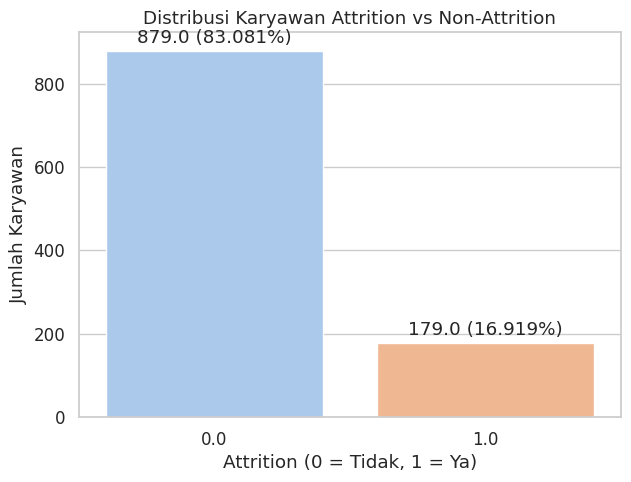

In [162]:
# Visualisasi Distribusi Target
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=data_hr_cleaned, palette='pastel')
plt.title('Distribusi Karyawan Attrition vs Non-Attrition')
plt.xlabel('Attrition (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Karyawan')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(data_hr_cleaned)*100:.3f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

Plot batang ini secara visual menegaskan ketidakseimbangan data yang parah. Anotasi menunjukkan bahwa hanya 16.919% dari dataset (yang telah dibersihkan) adalah karyawan yang keluar (Kelas 1), sementara 83.081% adalah karyawan yang bertahan (Kelas 0). Ketidakseimbangan ini berbahaya bagi model machine learning; jika tidak ditangani, model akan cenderung sangat akurat dalam memprediksi kelas mayoritas (Bertahan) tetapi sangat buruk dalam mengidentifikasi kelas minoritas (Keluar), yang seringkali merupakan tujuan utama bisnis.

## Analisis Fitur Numerik

In [163]:
# Analisis Kolom Konstan (Tidak Berguna)
print("\n--- Analisis Kolom dengan Variansi Rendah ---")
cols_to_drop = []
for col in data_hr_cleaned.columns:
    if data_hr_cleaned[col].nunique() == 1:
        cols_to_drop.append(col)
        print(f"Kolom '{col}' memiliki nilai konstan dan akan dihapus.")

# Tambahkan EmployeeId untuk dihapus
cols_to_drop.append('EmployeeId')


--- Analisis Kolom dengan Variansi Rendah ---
Kolom 'EmployeeCount' memiliki nilai konstan dan akan dihapus.
Kolom 'Over18' memiliki nilai konstan dan akan dihapus.
Kolom 'StandardHours' memiliki nilai konstan dan akan dihapus.


Fitur konstan (yaitu, setiap baris memiliki nilai yang sama) tidak memiliki varians, sehingga tidak memberikan informasi prediktif apa pun kepada model. Menghapusnya adalah praktik standar. 'EmployeeId' juga dihapus karena merupakan pengenal unik, bukan fitur prediktif.

In [164]:
# Distribusi Variabel Numerik
numerical_columns = data_hr_cleaned.select_dtypes(include=[np.number]).columns.tolist()
numerical_columns

['EmployeeId',
 'Age',
 'Attrition',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [165]:
numerical_description = data_hr_cleaned[numerical_columns].describe()
numerical_description

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.0,1058.000000,1058.000000,1058.00000,...,1058.000000,1058.0,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.00000,1058.000000,1058.000000
mean,736.656900,37.055766,0.169187,809.542533,8.978261,2.879017,1.0,2.712665,65.643667,2.73724,...,2.726843,80.0,0.762760,11.435728,2.769376,2.763705,7.065217,4.26087,2.203214,4.142722
std,427.440538,9.410421,0.375094,408.478049,8.040608,1.031442,0.0,1.092959,20.324861,0.70473,...,1.090970,0.0,0.837537,8.016429,1.302689,0.707392,6.265227,3.61747,3.266948,3.599044
min,2.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.00000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,364.250000,30.000000,0.000000,465.250000,2.000000,2.000000,1.0,2.000000,48.000000,2.00000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.00000,0.000000,2.000000
50%,731.500000,36.000000,0.000000,817.500000,7.000000,3.000000,1.0,3.000000,65.000000,3.00000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.00000,1.000000,3.000000
75%,1117.750000,43.000000,0.000000,1168.500000,13.000000,4.000000,1.0,4.000000,83.000000,3.00000,...,4.000000,80.0,1.000000,16.000000,3.000000,3.000000,9.000000,7.00000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.00000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.00000,15.000000,17.000000


Tabel ini mengonfirmasi temuan Sel 13 (EmployeeCount, Over18, dan StandardHours memiliki std = 0). Ini juga menunjukkan rentang nilai yang sangat berbeda antar fitur (misalnya, 'MonthlyIncome' memiliki mean ~8000-an dan maks 1499, sementara 'Education' hanya 1-5). Perbedaan skala ini menunjukkan perlunya feature scaling (penyekalaan fitur) sebelum pemodelan.

##Visualisasi Distribusi Kolom Numerik menggunakan histplot

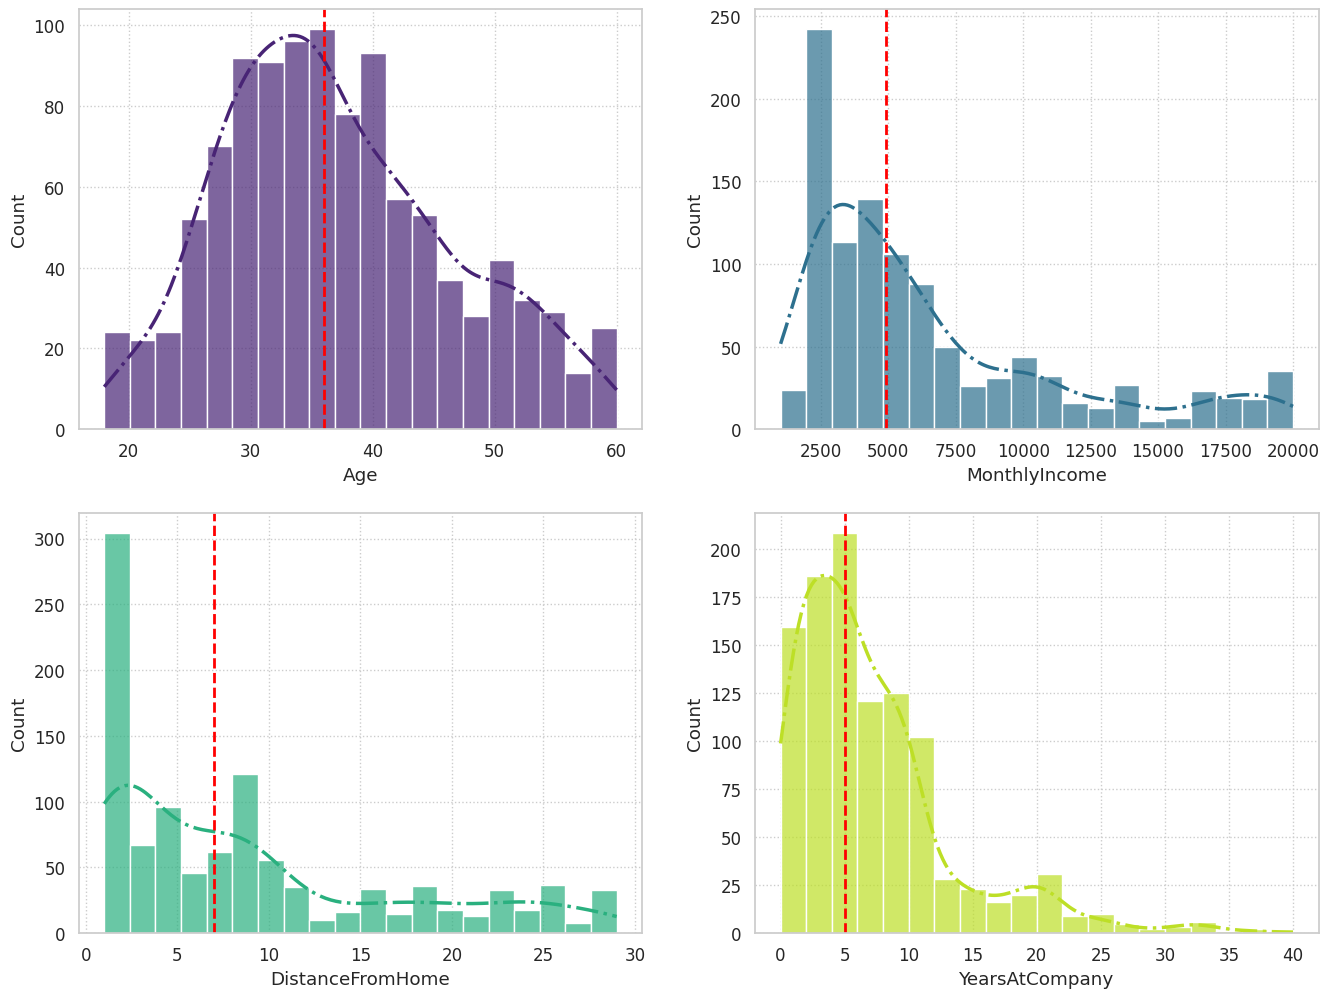

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


# --- 1. Persiapan Styling dan Data ---

# Mengatur style seaborn agar lebih bersih dan modern
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': ':'})
sns.set_context("notebook", font_scale=1.1)

# Daftar fitur yang akan di-plot
features_to_plot = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany']

# Judul yang lebih deskriptif untuk setiap plot
plot_titles = [
    'Distribusi Usia Karyawan',
    'Distribusi Pendapatan Bulanan (Monthly Income)',
    'Distribusi Jarak Rumah ke Kantor (Km)',
    'Distribusi Lama Bekerja di Perusahaan (Tahun)'
]

# Membuat palet warna yang menarik (menggunakan colormap 'viridis')
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(features_to_plot)))

# --- 2. Membuat Plot (Menggunakan Looping) ---

# Membuat layout subplot 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# 'axes.flatten()' mengubah matriks 2x2 menjadi array 1D agar mudah di-loop
for ax, feature, title, color in zip(axes.flatten(), features_to_plot, plot_titles, colors):

    # Hitung median untuk ditambahkan ke plot
    median_val = data_hr_cleaned[feature].median()

    # Plot Histplot + KDE (Kurva Densitas)
    sns.histplot(data_hr_cleaned[feature], bins=20, kde=True, ax=ax, color=color,
                 alpha=0.7, line_kws={'linewidth': 2.5, 'linestyle': '-.'})

    # Tambahkan garis median yang informatif
    ax.axvline(median_val, color='red', linestyle='--', linewidth=2,
               label=f'Median: {median_val:,.0f}')

    # --- 3. Kustomisasi T

* **Distribusi Usia**: Cukup normal (terdistribusi simetris), berpusat di sekitar usia pertengahan 30-an (Median: 36).

* **Distribusi Pendapatan Bulanan**: Sangat condong ke kanan (right-skewed). Sebagian besar karyawan berada di rentang gaji yang lebih rendah, dengan sedikit karyawan yang berpenghasilan sangat tinggi.

* **Distribusi Jarak Rumah**: Juga condong ke kanan. Mayoritas karyawan tinggal relatif dekat (Median: 7 km), tetapi ada ekor panjang (long tail) dari karyawan yang tinggal jauh.

* **Distribusi Lama Bekerja**: Juga condong ke kanan. Mayoritas karyawan memiliki masa kerja lebih pendek (Median: 5 tahun).

Analisis Hubungan fitur Numerik terhadap target Attrition

/tmp/ipython-input-1695025527.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1695025527.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipython-input-1695025527.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipython-input-1695025527.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Bertahan (Attrition = 0)', 'Keluar (Attrition = 1)'], fontsize=12)


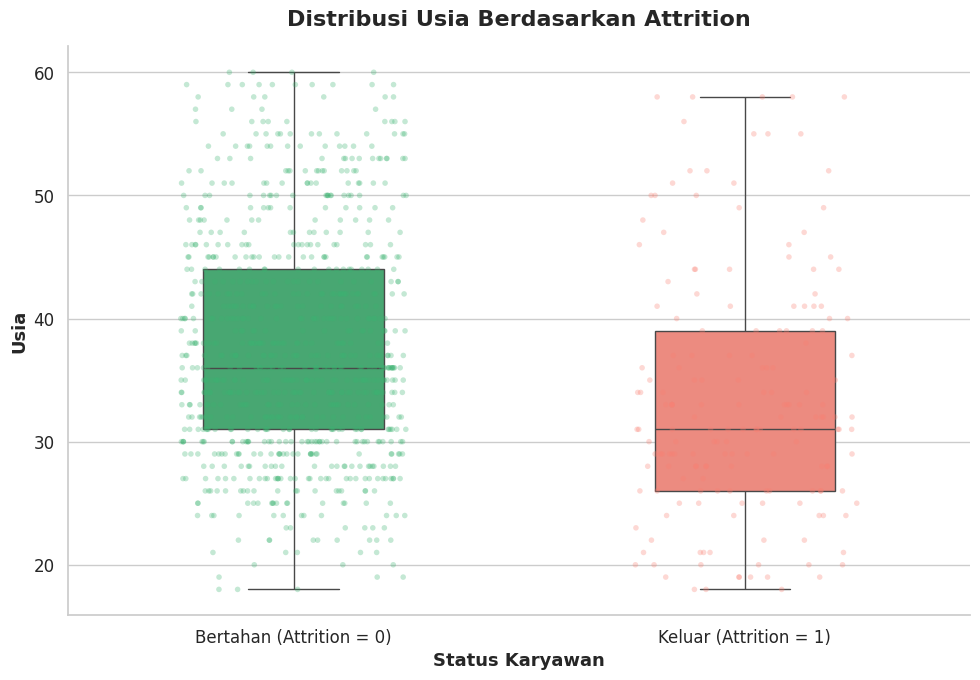

In [167]:
# --- 1. Persiapan Styling ---
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Membuat palet tematik yang lebih bercerita:
# 0 (Bertahan) = Hijau, 1 (Keluar) = Merah/Salmon
thematic_palette = {"mediumseagreen", "salmon"} # Updated keys to match float type

# --- 2. Membuat Plot Gabungan ---
plt.figure(figsize=(10, 7))

# Plot 1: Boxplot (Sebagai dasar)
# Kita sembunyikan 'outliers' bawaan (showfliers=False)
# karena stripplot akan menampilkannya.
sns.boxplot(
    data=data_hr_cleaned,
    x='Attrition',
    y='Age',
    palette=thematic_palette,
    showfliers=False,  # Outliers akan digambar oleh stripplot
    saturation=0.8,     # Sedikit kurangi saturasi warna box
    width=0.4           # Buat box lebih ramping
)

# Plot 2: Stripplot (Overlay)
# Ini akan menggambar semua poin data dengan 'jitter' (goyangan acak)
# agar tidak bertumpuk lurus.
sns.stripplot(
    data=data_hr_cleaned,
    x='Attrition',
    y='Age',
    palette=thematic_palette, # Gunakan palet yang sama
    jitter=0.25,        # Seberapa banyak 'goyangan'
    size=4,             # Ukuran poin data
    alpha=0.3,          # Transparansi agar densitas terlihat
    edgecolor='gray'    # Beri sedikit pinggiran pada poin
)

# --- 3. Kustomisasi Tampilan (Aesthetics) ---

# Mengambil 'axis' saat ini untuk kustomisasi
ax = plt.gca()

# Judul yang lebih kuat
ax.set_title("Distribusi Usia Berdasarkan Attrition", fontsize=16, weight='bold', pad=15)

# Label sumbu yang lebih deskriptif
ax.set_xlabel("Status Karyawan", fontsize=13, weight='bold')
ax.set_ylabel("Usia", fontsize=13, weight='bold')

# PENINGKATAN UTAMA: Mengganti label '0' dan '1'
ax.set_xticklabels(['Bertahan (Attrition = 0)', 'Keluar (Attrition = 1)'], fontsize=12)

# Membersihkan bingkai (spines) atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tampilkan plot
plt.tight_layout()
plt.show()

/tmp/ipython-input-3506356487.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-3506356487.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipython-input-3506356487.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipython-input-3506356487.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Bertahan (Attrition = 0)', 'Keluar (Attrition = 1)'], fontsize=12)


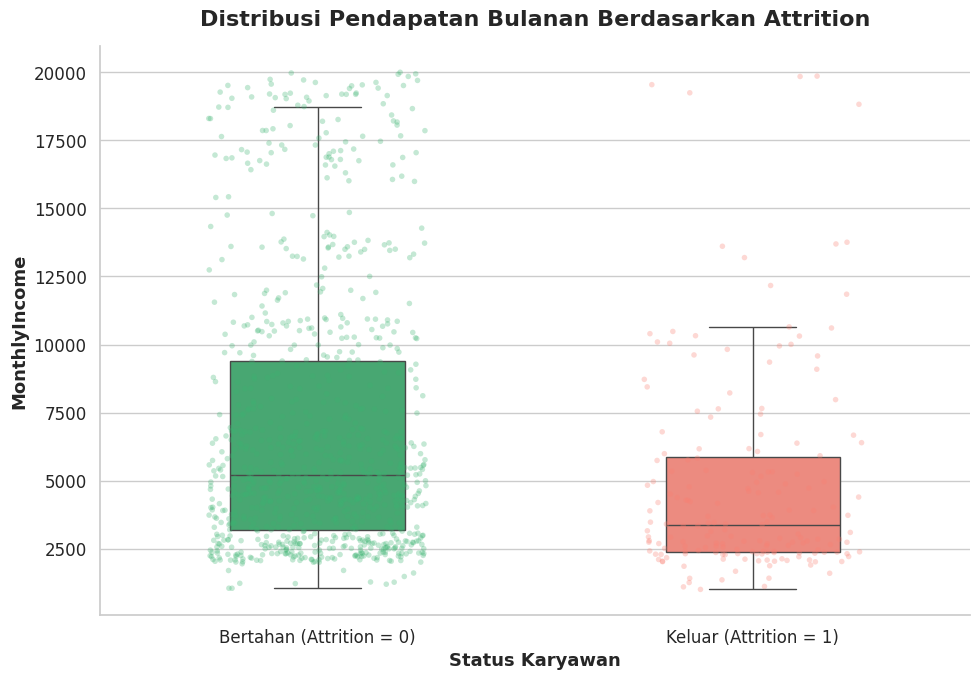

In [168]:
# --- 1. Persiapan Styling ---
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Membuat palet tematik yang lebih bercerita:
# 0 (Bertahan) = Hijau, 1 (Keluar) = Merah/Salmon
thematic_palette = {"mediumseagreen", "salmon"} # Updated keys to match float type

# --- 2. Membuat Plot Gabungan ---
plt.figure(figsize=(10, 7))

# Plot 1: Boxplot (Sebagai dasar)
# Kita sembunyikan 'outliers' bawaan (showfliers=False)
# karena stripplot akan menampilkannya.
sns.boxplot(
    data=data_hr_cleaned,
    x='Attrition',
    y='MonthlyIncome',
    palette=thematic_palette,
    showfliers=False,  # Outliers akan digambar oleh stripplot
    saturation=0.8,     # Sedikit kurangi saturasi warna box
    width=0.4           # Buat box lebih ramping
)

# Plot 2: Stripplot (Overlay)
# Ini akan menggambar semua poin data dengan 'jitter' (goyangan acak)
# agar tidak bertumpuk lurus.
sns.stripplot(
    data=data_hr_cleaned,
    x='Attrition',
    y='MonthlyIncome',
    palette=thematic_palette, # Gunakan palet yang sama
    jitter=0.25,        # Seberapa banyak 'goyangan'
    size=4,             # Ukuran poin data
    alpha=0.3,          # Transparansi agar densitas terlihat
    edgecolor='gray'    # Beri sedikit pinggiran pada poin
)

# --- 3. Kustomisasi Tampilan (Aesthetics) ---

# Mengambil 'axis' saat ini untuk kustomisasi
ax = plt.gca()

# Judul yang lebih kuat
ax.set_title("Distribusi Pendapatan Bulanan Berdasarkan Attrition", fontsize=16, weight='bold', pad=15)

# Label sumbu yang lebih deskriptif
ax.set_xlabel("Status Karyawan", fontsize=13, weight='bold')
ax.set_ylabel("MonthlyIncome", fontsize=13, weight='bold')

# PENINGKATAN UTAMA: Mengganti label '0' dan '1'
ax.set_xticklabels(['Bertahan (Attrition = 0)', 'Keluar (Attrition = 1)'], fontsize=12)

# Membersihkan bingkai (spines) atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tampilkan plot
plt.tight_layout()
plt.show()

/tmp/ipython-input-1941092323.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1941092323.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipython-input-1941092323.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipython-input-1941092323.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Bertahan (Attrition = 0)', 'Keluar (Attrition = 1)'], fontsize=12)


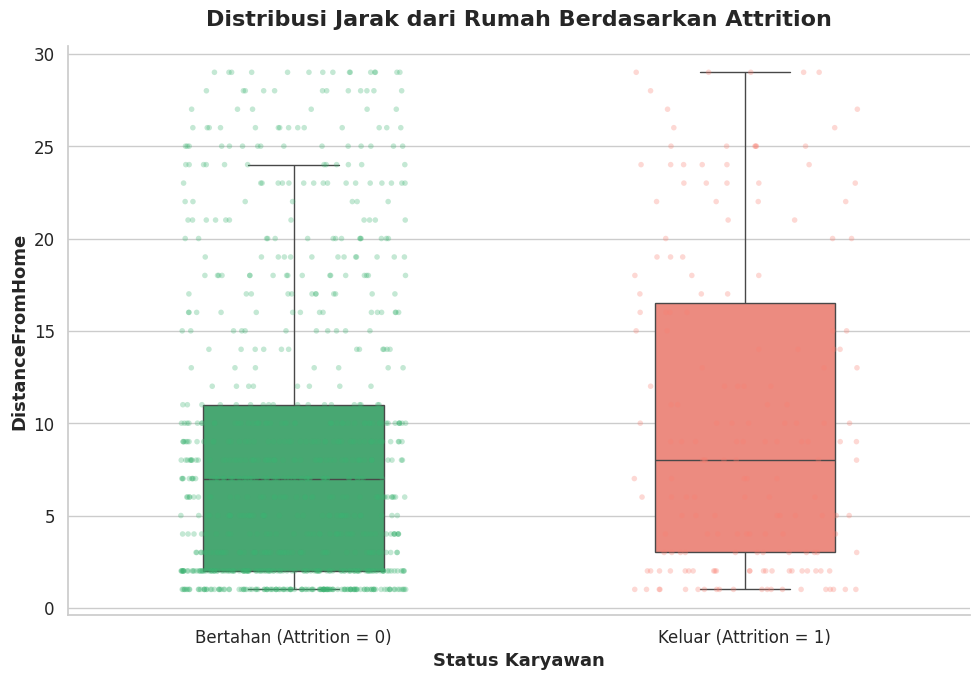

In [169]:
# --- 1. Persiapan Styling ---
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Membuat palet tematik yang lebih bercerita:
# 0 (Bertahan) = Hijau, 1 (Keluar) = Merah/Salmon
thematic_palette = {"mediumseagreen", "salmon"} # Updated keys to match float type

# --- 2. Membuat Plot Gabungan ---
plt.figure(figsize=(10, 7))

# Plot 1: Boxplot (Sebagai dasar)
# Kita sembunyikan 'outliers' bawaan (showfliers=False)
# karena stripplot akan menampilkannya.
sns.boxplot(
    data=data_hr_cleaned,
    x='Attrition',
    y='DistanceFromHome',
    palette=thematic_palette,
    showfliers=False,  # Outliers akan digambar oleh stripplot
    saturation=0.8,     # Sedikit kurangi saturasi warna box
    width=0.4           # Buat box lebih ramping
)

# Plot 2: Stripplot (Overlay)
# Ini akan menggambar semua poin data dengan 'jitter' (goyangan acak)
# agar tidak bertumpuk lurus.
sns.stripplot(
    data=data_hr_cleaned,
    x='Attrition',
    y='DistanceFromHome',
    palette=thematic_palette, # Gunakan palet yang sama
    jitter=0.25,        # Seberapa banyak 'goyangan'
    size=4,             # Ukuran poin data
    alpha=0.3,          # Transparansi agar densitas terlihat
    edgecolor='gray'    # Beri sedikit pinggiran pada poin
)

# --- 3. Kustomisasi Tampilan (Aesthetics) ---

# Mengambil 'axis' saat ini untuk kustomisasi
ax = plt.gca()

# Judul yang lebih kuat
ax.set_title("Distribusi Jarak dari Rumah Berdasarkan Attrition", fontsize=16, weight='bold', pad=15)

# Label sumbu yang lebih deskriptif
ax.set_xlabel("Status Karyawan", fontsize=13, weight='bold')
ax.set_ylabel("DistanceFromHome", fontsize=13, weight='bold')

# PENINGKATAN UTAMA: Mengganti label '0' dan '1'
ax.set_xticklabels(['Bertahan (Attrition = 0)', 'Keluar (Attrition = 1)'], fontsize=12)

# Membersihkan bingkai (spines) atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tampilkan plot
plt.tight_layout()
plt.show()

* **Usia** : Boxplot untuk 'Keluar (1.0)' secara jelas menunjukkan median dan rentang interkuartil yang lebih muda dibandingkan dengan mereka yang 'Bertahan (0.0)'. Ini menunjukkan bahwa karyawan yang lebih muda lebih cenderung untuk keluar.

* **Pendapatan Bulanan** : Tren serupa yang jelas terlihat. Median pendapatan untuk karyawan yang 'Keluar' secara signifikan lebih rendah daripada mereka yang 'Bertahan'.

* **Jarak dari Rumah** : Karyawan yang 'Keluar' cenderung tinggal sedikit lebih jauh (median lebih tinggi) daripada mereka yang 'Bertahan', meskipun ada banyak tumpang tindih antar kedua kelompok.

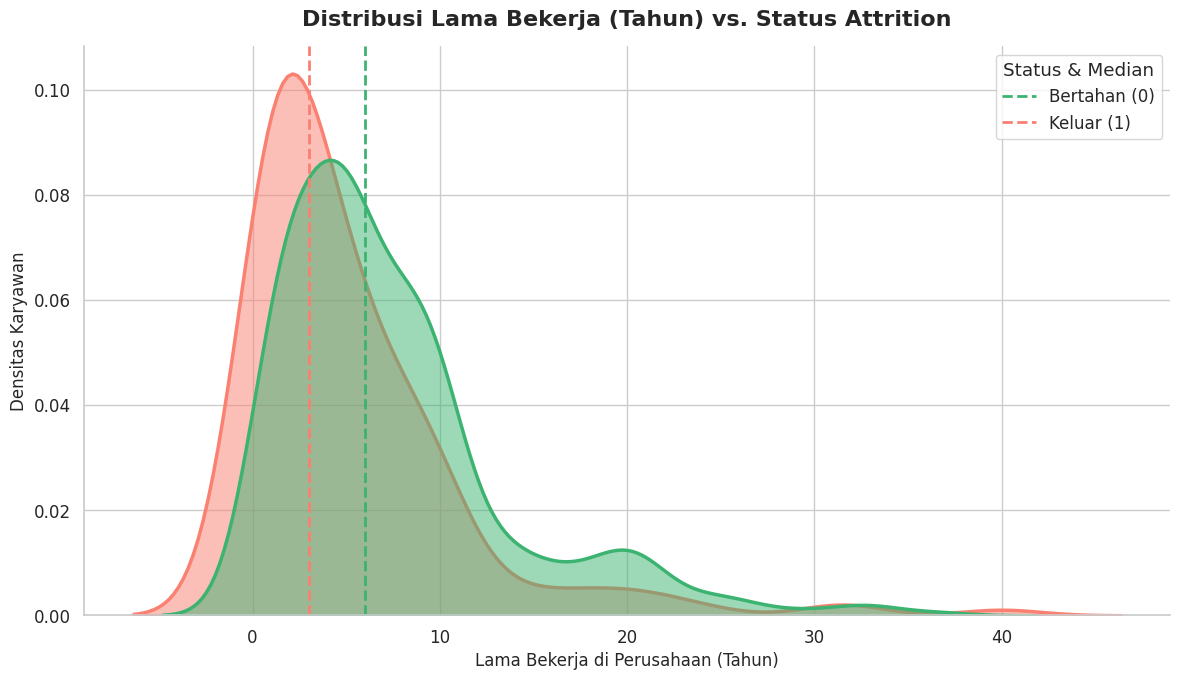

In [170]:
# Asumsi 'df' adalah DataFrame Anda

# --- 1. Persiapan Styling dan Data ---
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Palet tematik: 0 (Bertahan) = Hijau, 1 (Keluar) = Merah/Salmon
thematic_palette = {0: "mediumseagreen", 1: "salmon"}

# Hitung median untuk setiap grup
median_bertahan = data_hr_cleaned[data_hr_cleaned['Attrition'] == 0]['YearsAtCompany'].median()
median_keluar = data_hr_cleaned[data_hr_cleaned['Attrition'] == 1]['YearsAtCompany'].median()

# --- 2. Membuat Plot (KDE Plot) ---
plt.figure(figsize=(12, 7))
ax = plt.gca() # Ambil axis saat ini

# Plot KDE
sns.kdeplot(
    data=data_hr_cleaned,
    x="YearsAtCompany",
    hue="Attrition",
    palette=thematic_palette,
    fill=True,
    common_norm=False,
    alpha=0.5,
    linewidth=2.5,
    ax=ax # Tentukan axis untuk plot
)

# --- 3. Menambahkan Garis Median (Informatif) ---
ax.axvline(
    median_bertahan,
    color=thematic_palette[0],
    linestyle='--',
    linewidth=2,
    label=f'Median Bertahan: {median_bertahan:.0f} thn' # Label untuk legenda
)
ax.axvline(
    median_keluar,
    color=thematic_palette[1],
    linestyle='--',
    linewidth=2,
    label=f'Median Keluar: {median_keluar:.0f} thn' # Label untuk legenda
)

# --- 4. Kustomisasi Tampilan (Aesthetics) ---

# Judul dan Label
ax.set_title("Distribusi Lama Bekerja (Tahun) vs. Status Attrition", fontsize=16, weight='bold', pad=15)
ax.set_xlabel("Lama Bekerja di Perusahaan (Tahun)", fontsize=12)
ax.set_ylabel("Densitas Karyawan", fontsize=12)

# --- PERBAIKAN KODE LEGEND ---
# Ambil handles dan labels dari axis
handles, labels = ax.get_legend_handles_labels()

# Modifikasi label untuk '0' dan '1' (yang berasal dari 'hue')
# Asumsi 2 label pertama adalah dari KDE plot
if len(labels) > 1:
    labels[0] = 'Bertahan (0)'
    labels[1] = 'Keluar (1)'

# Terapkan legenda baru
ax.legend(handles, labels, title="Status & Median", facecolor='white', framealpha=0.8)

# Membersihkan bingkai
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Plot ini sangat mengungkapkan. Puncak kurva untuk Attrition=1.0 (Keluar) berada secara signifikan di sebelah kiri (pada nilai tahun yang sangat rendah) dibandingkan puncak untuk Attrition=0.0. Ini menunjukkan bahwa risiko attrition paling tinggi terjadi pada karyawan yang sangat baru (sekitar 0-2 tahun masa kerja).

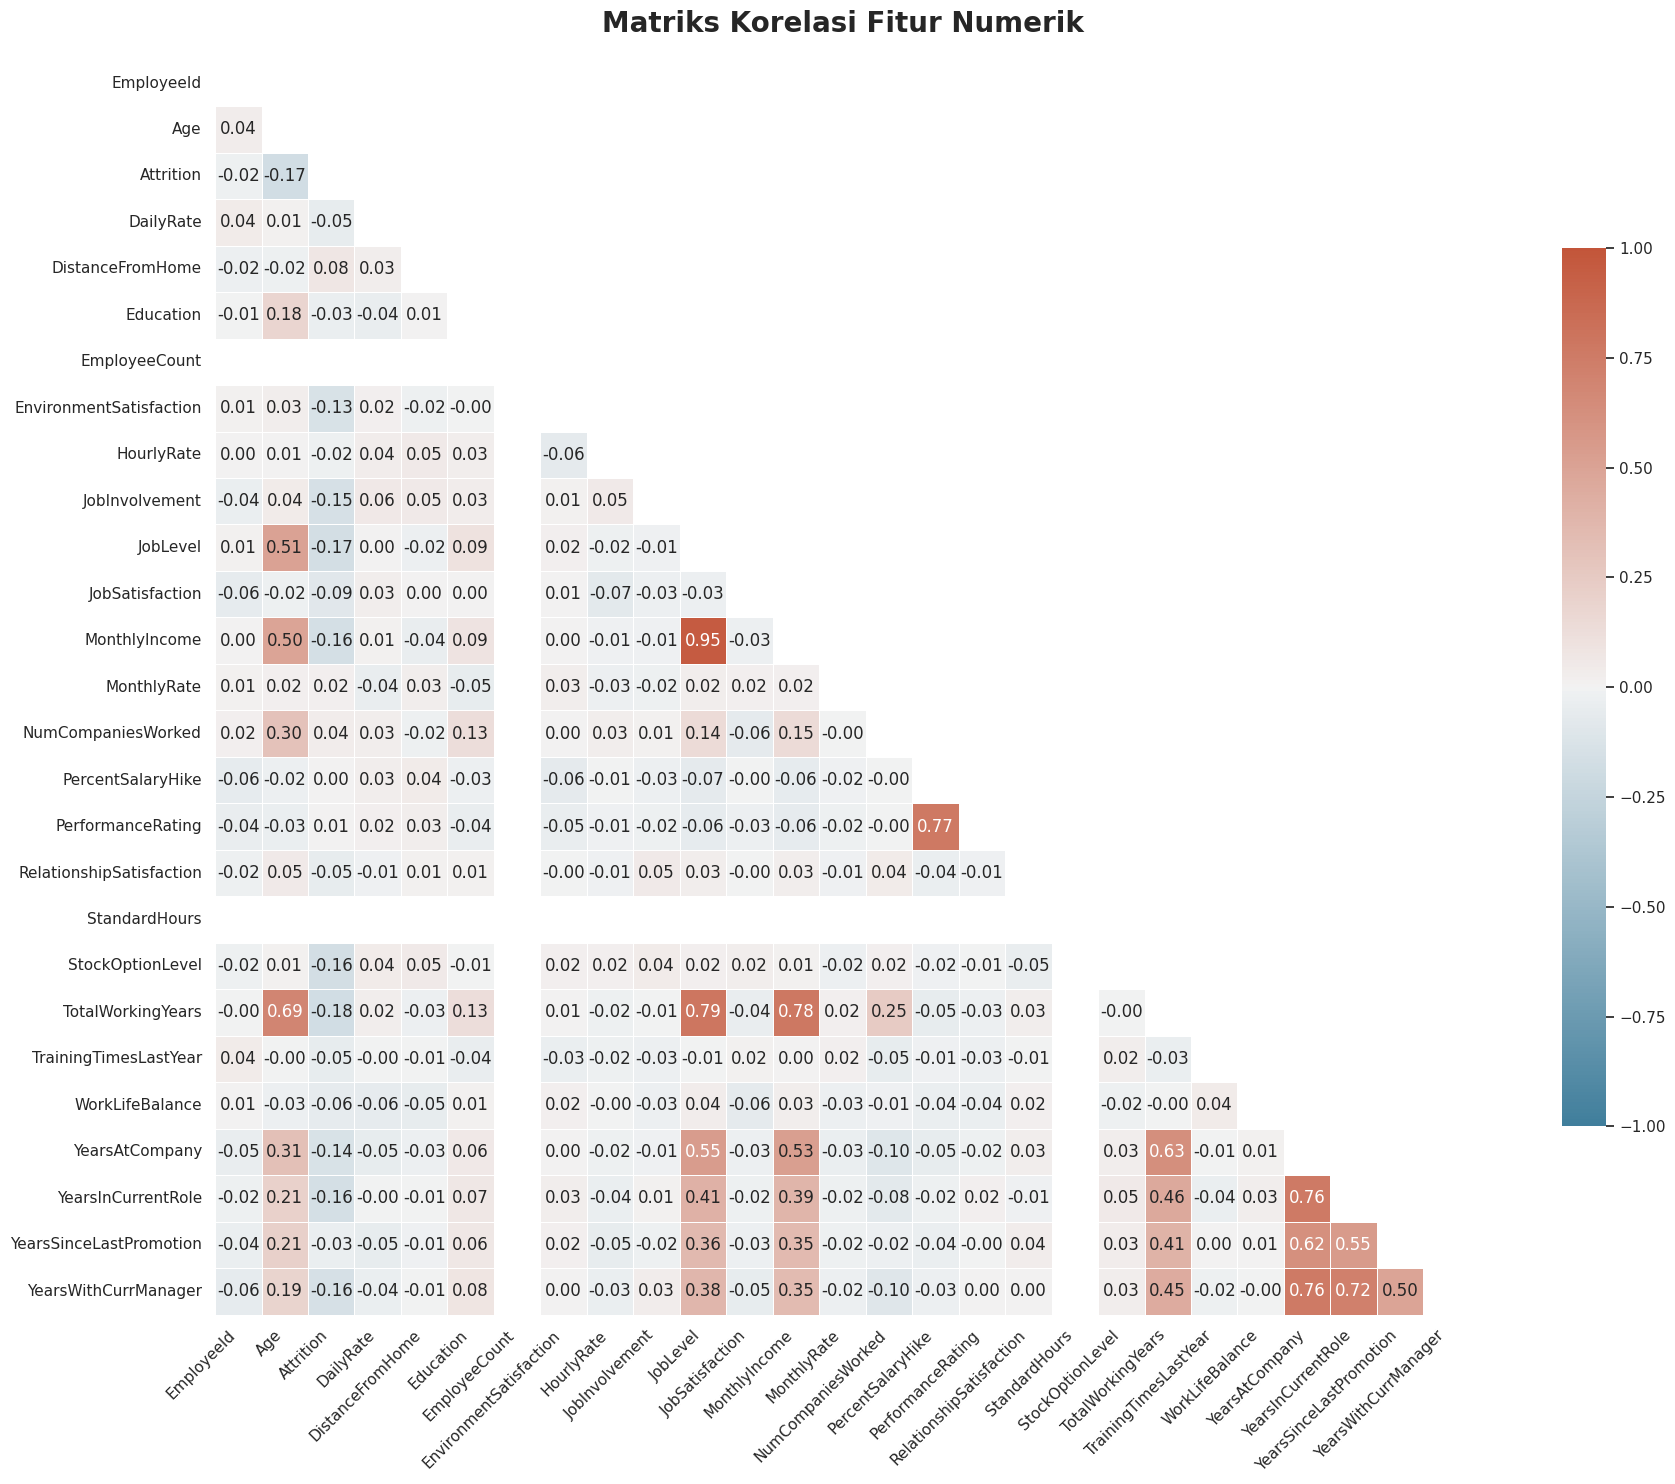

In [171]:
df_numeric = data_hr_cleaned.select_dtypes(include=np.number)

# Hitung korelasi
corr_matrix = df_numeric.corr()

# Buat 'mask' untuk menyembunyikan bagian atas matriks (karena duplikat)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# --- 2. Membuat Plot ---
plt.figure(figsize=(20, 15)) # Butuh ukuran besar
sns.set_theme(style="white")

# Gunakan diverging palette (merah-putih-biru)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,          # Terapkan mask
    cmap=cmap,          # Peta warna
    vmax=1.0,           # Set nilai maks/min untuk warna
    vmin=-1.0,
    center=0,           # Pusatkan warna di 0
    square=True,        # Buat sel menjadi persegi
    linewidths=.5,      # Garis antar sel
    annot=True,         # Tampilkan angka korelasi
    fmt=".2f",          # Format angka (2 desimal)
    cbar_kws={"shrink": .7} # Kecilkan color bar
)

# --- 3. Kustomisasi Tampilan ---
plt.title('Matriks Korelasi Fitur Numerik', fontsize=20, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Grafik ini membandingkan distribusi usia antara dua kelompok karyawan: mereka yang Bertahan (0) dan mereka yang Keluar (1) dari perusahaan.

**Temuan Kunci:**
* Median Usia: Terdapat perbedaan yang jelas pada median (garis tengah kotak) antara kedua kelompok. Karyawan yang Keluar (1) memiliki median usia yang lebih rendah (diperkirakan sekitar 30-31 tahun) dibandingkan dengan karyawan yang Bertahan (0) (diperkirakan sekitar 36-37 tahun).

* Rentang Interkuartil (IQR): Seluruh rentang 50% tengah (kotak) untuk kelompok "Keluar" bergeser ke bawah. Ini menunjukkan bahwa mayoritas (bagian tengah) dari karyawan yang keluar secara konsisten lebih muda daripada mayoritas karyawan yang bertahan.

* Konsentrasi Data (Stripplot): Plot titik (titik-titik data individual) secara visual mengonfirmasi temuan ini. Kumpulan titik untuk kategori "Keluar (1)" jauh lebih padat di rentang usia yang lebih muda (terutama di bawah 40 tahun). Sebaliknya, titik-titik untuk "Bertahan (0)" terdistribusi lebih merata di rentang usia yang lebih luas, dengan konsentrasi di usia 30-an hingga pertengahan 40-an.

* Outlier (Pencilan): Meskipun tren utamanya adalah karyawan muda yang keluar, data juga menunjukkan adanya beberapa karyawan yang lebih tua (misalnya, di atas 50 tahun) yang juga keluar, yang terlihat sebagai titik-titik di atas "kumis" (whisker) dari boxplot "Keluar". Namun, ini adalah kasus yang lebih jarang terjadi.

<Figure size 1200x800 with 0 Axes>

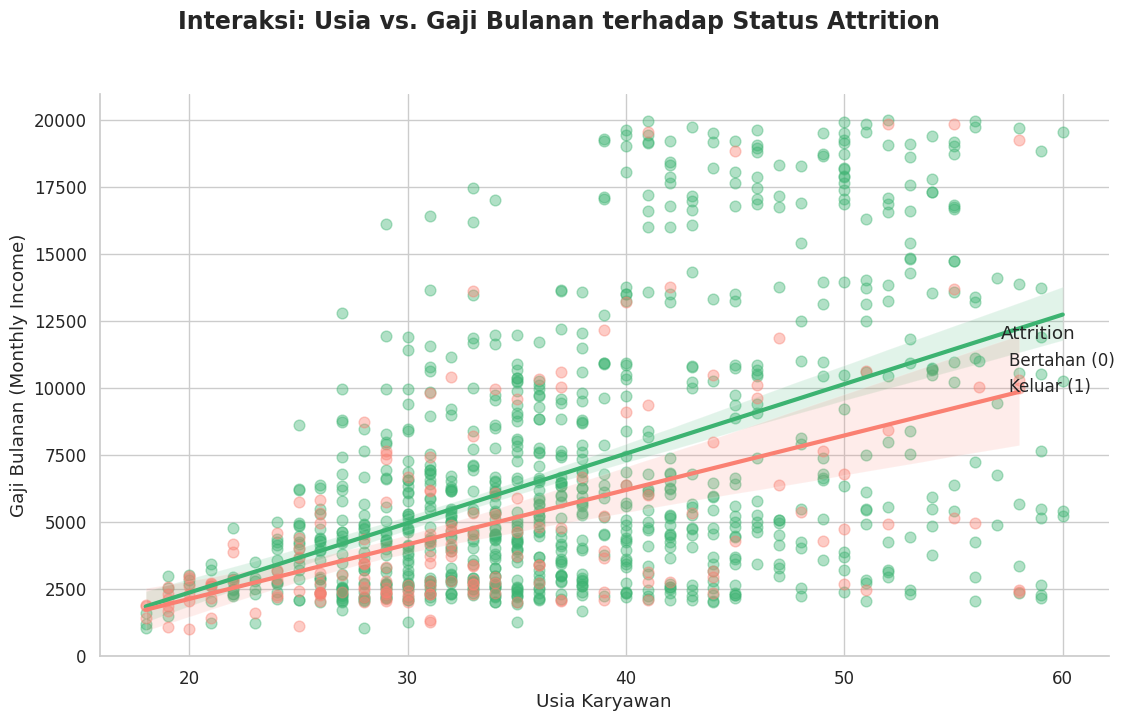

In [172]:
# --- 1. Persiapan Styling ---
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Palet tematik: 0 (Bertahan) = Hijau, 1 (Keluar) = Merah/Salmon
thematic_palette = {0: "mediumseagreen", 1: "salmon"}

# --- 2. Membuat Plot ---
plt.figure(figsize=(12, 8))

# Menggunakan lmplot (atau regplot) untuk menambahkan garis regresi
# Ini menunjukkan tren dengan lebih baik daripada scatterplot biasa
g = sns.lmplot(
    data=data_hr_cleaned,
    x='Age',
    y='MonthlyIncome',
    hue='Attrition',        # Kunci interaksi
    palette=thematic_palette,
    height=7,
    aspect=1.5,
    scatter_kws={'alpha': 0.4, 's': 60}, # Kustomisasi poin
    line_kws={'lw': 3}                  # Kustomisasi garis regresi
)

# --- 3. Kustomisasi Tampilan ---
g.fig.suptitle('Interaksi: Usia vs. Gaji Bulanan terhadap Status Attrition',
               y=1.03, fontsize=17, weight='bold')

g.set_axis_labels("Usia Karyawan", "Gaji Bulanan (Monthly Income)")

# Mengatur label legenda
new_labels = ['Bertahan (0)', 'Keluar (1)']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

plt.tight_layout()
plt.show()

Grafik ini memvisualisasikan hubungan antara status kerja lembur (OverTime) karyawan dengan keputusan mereka untuk bertahan (Attrition=0) atau keluar (Attrition=1).

**Kelompok "Tidak Lembur" (No):**

* Bagi karyawan yang tidak bekerja lembur, jumlah yang Bertahan (0) (batang biru) sangat dominan, mencapai lebih dari 700 karyawan.

* Jumlah karyawan yang Keluar (1) (batang oranye) di kelompok ini sangat kecil, hanya sekitar 100 karyawan.

* Analisis: Ini menunjukkan bahwa karyawan yang tidak bekerja lembur memiliki loyalitas yang sangat tinggi dan tingkat attrition yang sangat rendah.

**Kelompok "Lembur" (Yes):**

* Jumlah total karyawan yang bekerja lembur jauh lebih sedikit dibandingkan yang tidak.

* Perbedaan paling mencolok ada di kelompok ini. Jumlah karyawan yang Bertahan (0) (batang biru, sekitar 150) hampir sama banyaknya dengan jumlah karyawan yang Keluar (1) (batang oranye, sekitar 120-130).

* Analisis: Ini adalah temuan kritis. Proporsi attrition di antara karyawan yang bekerja lembur sangat tinggi. Tingkat attrition di kelompok ini mendekati 50%, yang merupakan angka yang sangat mengkhawatirkan.

**Grafik ini dengan jelas menunjukkan bahwa bekerja lembur (OverTime) adalah salah satu faktor pendorong (driver) atau prediktor terkuat untuk attrition.**

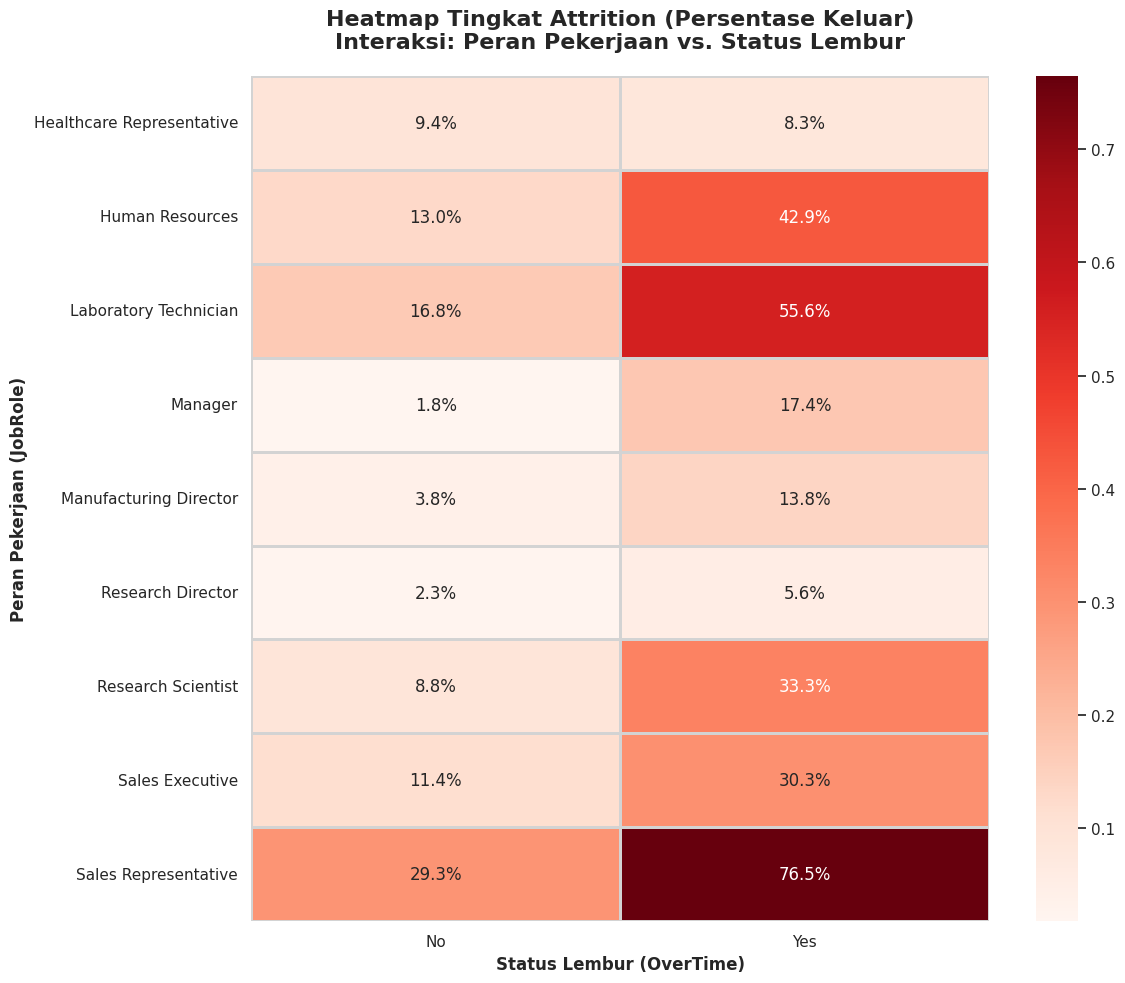

In [173]:
# --- 1. Persiapan Data (Pivot Table) ---
# Hitung rata-rata Attrition (yang = persentase Attrition)
# untuk setiap kombinasi JobRole dan OverTime
pivot_data = data_hr_cleaned.pivot_table(
    index='JobRole',
    columns='OverTime',
    values='Attrition',
    aggfunc='mean' # Rata-rata dari 0 dan 1 adalah persentase
)

# --- 2. Membuat Plot ---
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

sns.heatmap(
    pivot_data,
    annot=True,         # Tampilkan angka
    fmt=".1%",          # Format sebagai persentase
    cmap="Reds",        # Gunakan 'Reds' karena 0% = 'dingin', 100% = 'panas'
    linewidths=1,
    linecolor='lightgray',
    cbar=True
)

# --- 3. Kustomisasi Tampilan ---
plt.title('Heatmap Tingkat Attrition (Persentase Keluar)\nInteraksi: Peran Pekerjaan vs. Status Lembur',
          fontsize=16, weight='bold', pad=20)
plt.xlabel('Status Lembur (OverTime)', fontsize=12, weight='bold')
plt.ylabel('Peran Pekerjaan (JobRole)', fontsize=12, weight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Grafik ini menyajikan perbandingan attrition (pengunduran diri karyawan) berdasarkan tiga kategori status pernikahan: "Married" (Menikah), "Single" (Lajang), dan "Divorced" (Cerai).

**Status "Single" (Lajang):**

* Kelompok ini menunjukkan tingkat attrition tertinggi secara signifikan.

* Batang oranye ("Keluar - 1") untuk "Single" adalah yang tertinggi secara absolut di antara ketiga kategori, menunjukkan jumlah karyawan lajang yang keluar adalah yang paling banyak.

* Secara proporsional, rasio antara yang "Keluar" (oranye) dan yang "Bertahan" (biru) juga tampak paling tinggi di kelompok ini, menunjukkan risiko turnover yang besar.

**Status "Married" (Menikah):**

* Kelompok ini memiliki jumlah karyawan "Bertahan" (biru) tertinggi secara absolut, menunjukkan bahwa ini adalah kelompok demografis terbesar di perusahaan.

* Tingkat attrition (batang oranye) secara proporsional jauh lebih rendah dibandingkan dengan kelompok "Single". Mayoritas besar karyawan yang menikah cenderung bertahan.

**Status "Divorced" (Cerai):**

* Kelompok ini menunjukkan tingkat attrition yang paling rendah dari ketiganya.

* Batang oranye ("Keluar - 1") adalah yang paling pendek, baik secara absolut maupun proporsional, relatif terhadap jumlah karyawan yang "Bertahan". Ini menunjukkan stabilitas karyawan yang tinggi dalam kelompok ini.


Status pernikahan (MaritalStatus) tampak jelas sebagai prediktor kuat untuk attrition. Karyawan yang "Single" (Lajang) adalah kelompok yang paling rentan dan memiliki risiko keluar tertinggi. Sebaliknya, karyawan yang "Married" (Menikah) dan terutama yang "Divorced" (Cerai) menunjukkan tingkat stabilitas dan retensi yang jauh lebih tinggi.

##Analisis Tingkat Kepuasan Karyawan

Distribusi Kepuasan Kerja (Donut Chart)

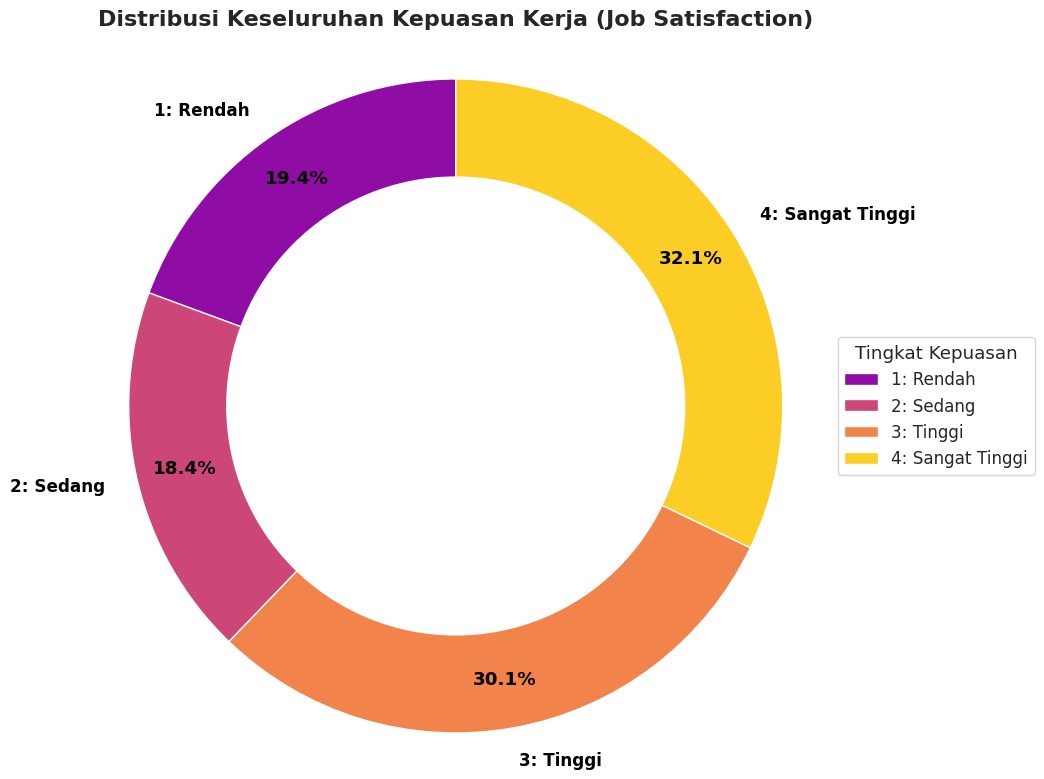

In [174]:
# --- 1. Persiapan Data ---
# Hitung jumlah untuk setiap level kepuasan
satisfaction_counts = data_hr_cleaned['JobSatisfaction'].value_counts().sort_index()

# Buat label yang deskriptif
labels_map = {1: '1: Rendah', 2: '2: Sedang', 3: '3: Tinggi', 4: '4: Sangat Tinggi'}
plot_labels = satisfaction_counts.index.map(labels_map)
plot_sizes = satisfaction_counts.values

# Warna (palette 'plasma' terlihat bagus untuk ini)
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(plot_labels)))

# --- 2. Membuat Plot (Donut Chart) ---
plt.figure(figsize=(10, 8))
sns.set_context("notebook", font_scale=1.1)

# Gambar Pie Chart
wedges, texts, autotexts = plt.pie(
    plot_sizes,
    labels=plot_labels,
    colors=colors,
    autopct='%1.1f%%',  # Tampilkan persentase
    startangle=90,      # Mulai dari atas
    pctdistance=0.85,   # Jarak label persentase dari pusat
    textprops={'color':"black", 'weight':'bold'}
)

# Gambar lingkaran putih di tengah untuk membuatnya jadi Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# --- 3. Kustomisasi Tampilan ---
plt.title('Distribusi Keseluruhan Kepuasan Kerja (Job Satisfaction)',
          fontsize=16, weight='bold', pad=15)
plt.axis('equal')  # Pastikan lingkaran terlihat bulat

# Legenda
plt.legend(wedges, plot_labels,
          title="Tingkat Kepuasan",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

Tingkat Attrition di Setiap Metrik Kepuasan (100% Stacked Bar)


Grafik ini menggunakan Kernel Density Estimation (KDE) plot untuk membandingkan distribusi masa kerja (tenure) antara karyawan yang Bertahan (0.0) dan yang Keluar (1.0).

**Temuan Kunci:**
1. **Risiko Attrition di Awal Masa Kerja:**

* Kurva oranye ("Keluar - 1.0") menunjukkan puncak (peak) yang sangat tinggi dan tajam di sisi paling kiri sumbu X, yaitu pada masa kerja yang sangat singkat (diperkirakan antara 0 hingga 2 tahun).

* Analisis: Ini adalah temuan yang paling mencolok. Risiko attrition tertinggi secara masif terjadi pada karyawan yang baru bergabung. Setelah melewati 2-3 tahun pertama, probabilitas (kepadatan) karyawan untuk keluar turun secara drastis dan tetap sangat rendah.

2. Pola Retensi Karyawan:

* Kurva biru ("Bertahan - 0.0") memiliki puncak yang sedikit lebih lambat (diperkirakan sekitar 3-5 tahun) dan distribusi yang jauh lebih menyebar (lebar) ke kanan.

* Analisis: Ini menunjukkan bahwa karyawan yang cenderung bertahan adalah mereka yang telah melewati "masa kritis" 0-2 tahun pertama. Perusahaan memiliki populasi karyawan yang substansial yang bertahan selama 3-10 tahun, dan juga berhasil mempertahankan sekelompok kecil karyawan (ekor panjang atau long tail) untuk jangka waktu yang sangat lama (10 hingga 40 tahun).

**Kesimpulan:**
Masa kerja di perusahaan (YearsAtCompany) adalah prediktor yang sangat kuat untuk attrition. Temuan utama dari grafik ini adalah bahwa periode 0-2 tahun pertama adalah periode paling rentan untuk turnover karyawan.

Implikasi bisnisnya adalah bahwa program retensi harus difokuskan secara intensif pada proses onboarding dan pengalaman karyawan baru. Memastikan karyawan baru terintegrasi dengan baik, mendapatkan dukungan yang memadai, dan merasa terlibat sejak awal sangat krusial untuk mengurangi tingkat attrition secara keseluruhan.

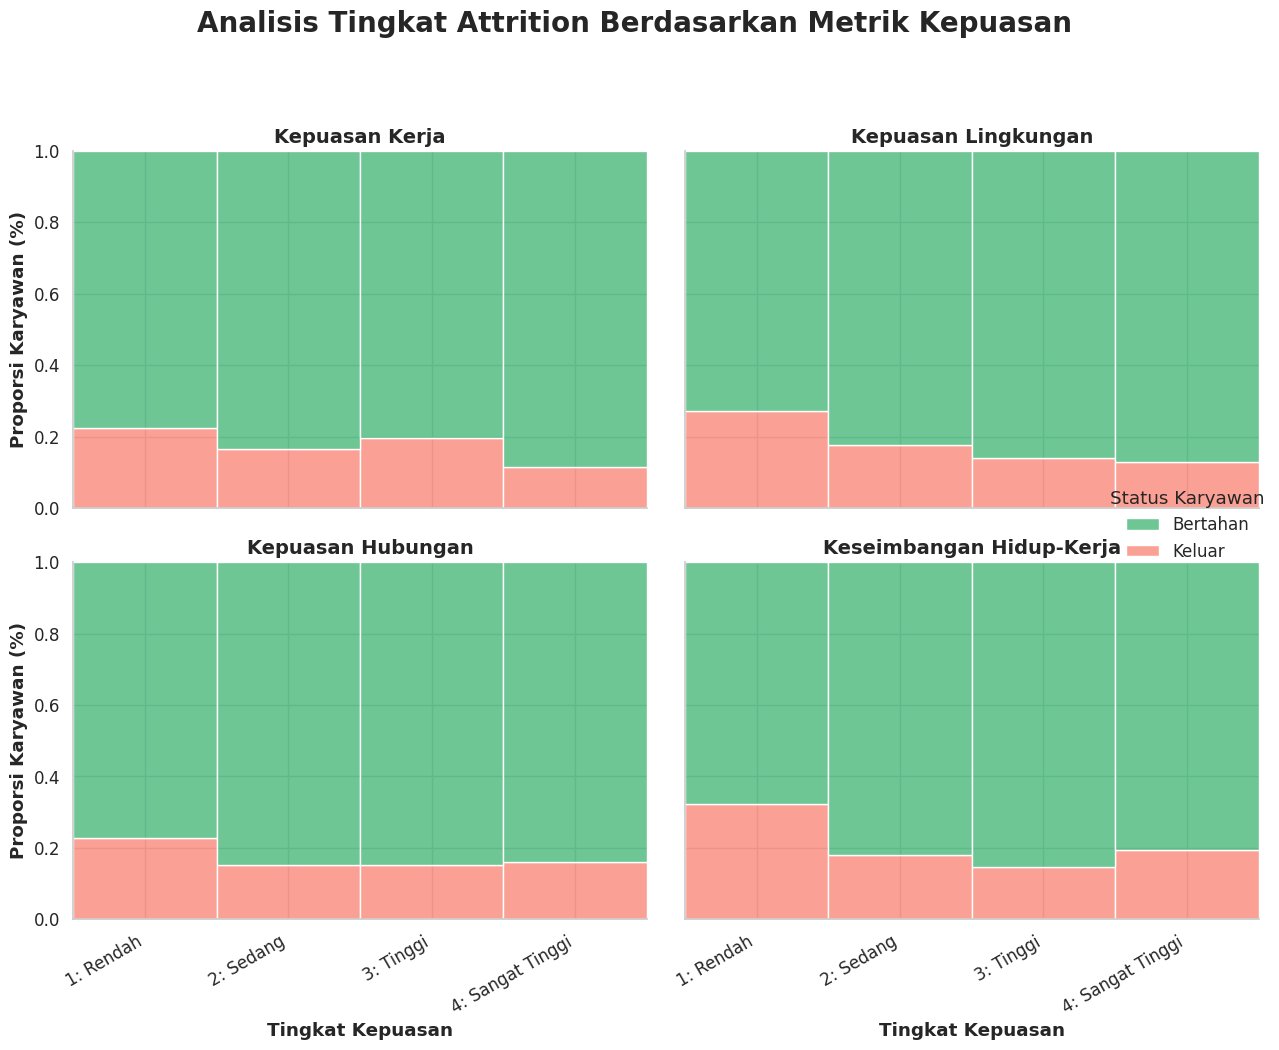

In [175]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']
renamed_cols_map = {
    'JobSatisfaction': 'Kepuasan Kerja',
    'EnvironmentSatisfaction': 'Kepuasan Lingkungan',
    'RelationshipSatisfaction': 'Kepuasan Hubungan',
    'WorkLifeBalance': 'Keseimbangan Hidup-Kerja'
}
cols_to_melt = [col for col in satisfaction_cols if col in data_hr_cleaned.columns]
df_melted = data_hr_cleaned.melt(
    id_vars=['Attrition'],
    value_vars=cols_to_melt,
    var_name='Metrik Kepuasan',
    value_name='Skor (1-4)'
)
df_melted['Metrik Kepuasan'] = df_melted['Metrik Kepuasan'].map(renamed_cols_map)
df_melted = df_melted.dropna(subset=['Metrik Kepuasan'])

# --- 2. Membuat Plot (Faceted 100% Stacked Bar) ---
# (Kode ini sama seperti sebelumnya, sudah benar)
sns.set_style("whitegrid")
thematic_palette = {0: "mediumseagreen", 1: "salmon"}

g = sns.displot(
    data=df_melted,
    x='Skor (1-4)',
    hue='Attrition',
    col='Metrik Kepuasan',
    col_wrap=2,
    kind='hist',
    discrete=True,
    stat='percent',
    multiple='fill',
    palette=thematic_palette,
    height=5,
    aspect=1.2
)

# --- 3. Kustomisasi Tampilan (INI BAGIAN YANG DIPERBAIKI) ---
g.fig.suptitle('Analisis Tingkat Attrition Berdasarkan Metrik Kepuasan',
               y=1.05, fontsize=20, weight='bold')

# Label sumbu (masih menggunakan 'g' untuk label utama)
g.set_xlabels("Tingkat Kepuasan", weight='bold')
g.set_ylabels("Proporsi Karyawan (%)", weight='bold')

# Label untuk legenda
new_labels = ['Bertahan', 'Keluar']
leg = g._legend
leg.set_title("Status Karyawan")
for t, l in zip(leg.texts, new_labels):
    t.set_text(l)

# --- PERBAIKAN UTAMA DI SINI ---
# Kita harus melakukan iterasi pada setiap subplot (axes)
# dan mengatur Ticks DAN TickLabels-nya
custom_labels = ['1: Rendah', '2: Sedang', '3: Tinggi', '4: Sangat Tinggi']
custom_ticks = [1, 2, 3, 4] # Lokasi data kita

for ax in g.axes.flatten():
    # 1. Atur LOKASI ticks secara manual
    ax.set_xticks(custom_ticks)
    # 2. SEKARANG baru atur LABEL untuk lokasi tersebut
    ax.set_xticklabels(custom_labels, rotation=30, ha='right')

    # Kustomisasi judul dan bingkai (ini opsional, tapi rapi)
    ax.set_title(ax.get_title().replace("Metrik Kepuasan = ", ""), weight='bold', size=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# --- AKHIR PERBAIKAN ---

plt.tight_layout()
plt.show()

Grafik ini adalah sebuah heatmap yang merepresentasikan Confusion Matrix (Matriks Kebingungan). Matriks ini mengevaluasi kinerja model XGBoost final (yang telah di-tuning) pada data pengujian (test set).

Matriks ini membandingkan prediksi model (Sumbu X: Prediksi 0 atau 1) dengan kenyataan sebenarnya (Sumbu Y: Aktual 0 atau 1).

Penjabaran Hasil (Empat Kuadran):

1. True Negative (TN) - Kiri Atas: 152

Aktual 0, Prediksi 0.

Analisis: Model dengan benar memprediksi 152 karyawan akan Bertahan, dan mereka memang Bertahan. Ini adalah prediksi yang benar untuk kelas mayoritas.

2. False Positive (FP) - Kanan Atas: 24

Aktual 0, Prediksi 1.

Analisis: Model salah memprediksi 24 karyawan akan Keluar, padahal kenyataannya mereka Bertahan. Ini adalah error Tipe I. Dalam konteks bisnis, ini adalah kesalahan yang biayanya lebih rendah (misalnya, tim HR mungkin memberikan perhatian ekstra pada karyawan yang sebenarnya tidak berisiko keluar).

3. False Negative (FN) - Kiri Bawah: 16

Aktual 1, Prediksi 0.

Analisis: Model salah memprediksi 16 karyawan akan Bertahan, padahal kenyataannya mereka Keluar. Ini adalah error Tipe II dan merupakan kesalahan paling kritis dalam kasus attrition. Ini adalah 16 karyawan berisiko tinggi yang gagal diidentifikasi oleh model.

4. True Positive (TP) - Kanan Bawah: 20

Aktual 1, Prediksi 1.

Analisis: Model dengan benar memprediksi 20 karyawan akan Keluar, dan mereka memang Keluar. Ini adalah keberhasilan utama model dalam mengidentifikasi kelas minoritas (target).

**Kesimpulan:**
* Model ini sangat baik dalam mengidentifikasi karyawan yang tidak akan keluar (152 prediksi benar vs 24 prediksi salah).

* Tujuan utama model adalah mengidentifikasi karyawan yang akan keluar (Kelas 1). Model ini berhasil menemukan 20 kasus (TP) tetapi melewatkan 16 kasus (FN).

* Dari total 36 karyawan yang sebenarnya keluar di data uji (16 FN + 20 TP), model ini berhasil mengidentifikasi 20 di antaranya. Ini menghasilkan metrik Recall sebesar 56% (20/(16+20)=0.555...), yang menunjukkan keberhasilan model setelah di-tuning secara khusus untuk mengoptimalkan recall.

**Hubungan Fitur Kategorikal terhadap Target**

In [176]:
# Distribusi Kolom Kategorikal
categorical_columns = data_hr_cleaned.select_dtypes(exclude=[np.number]).columns.tolist()
categorical_columns

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

--- Visualisasi Proporsi Attrition per Fitur Kategorikal (Ditingkatkan) ---


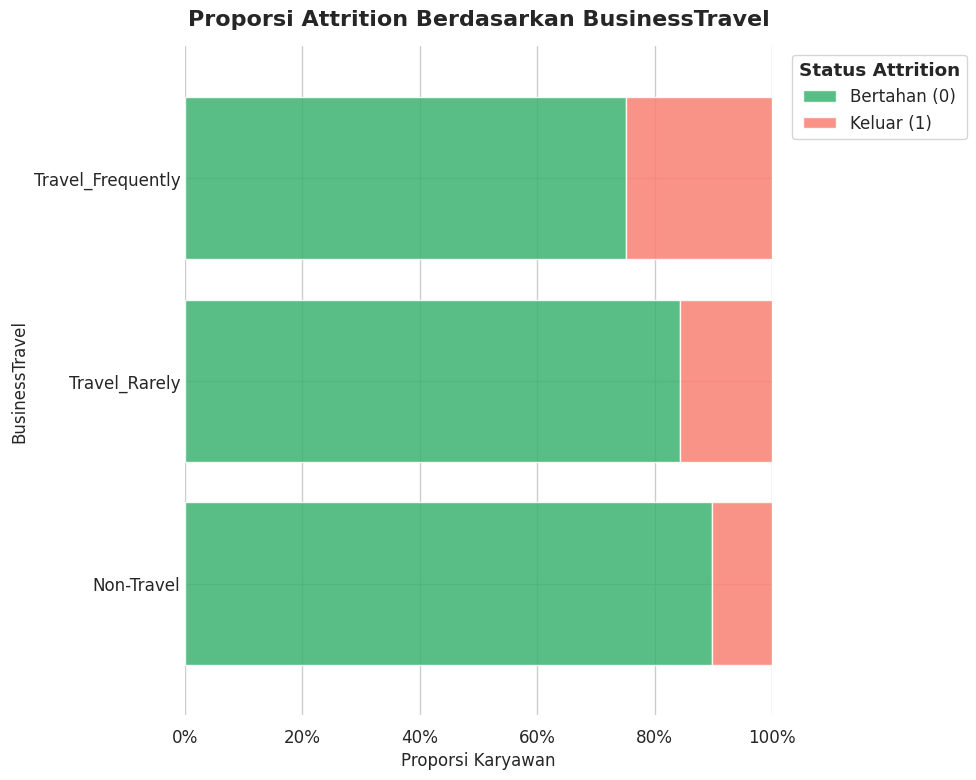

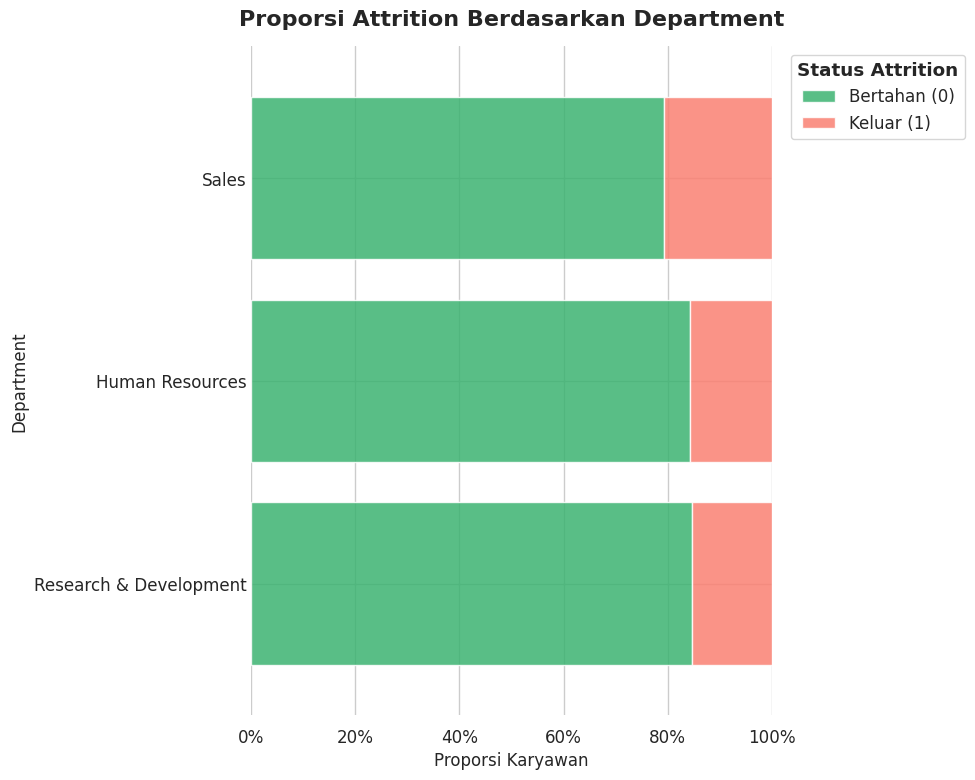

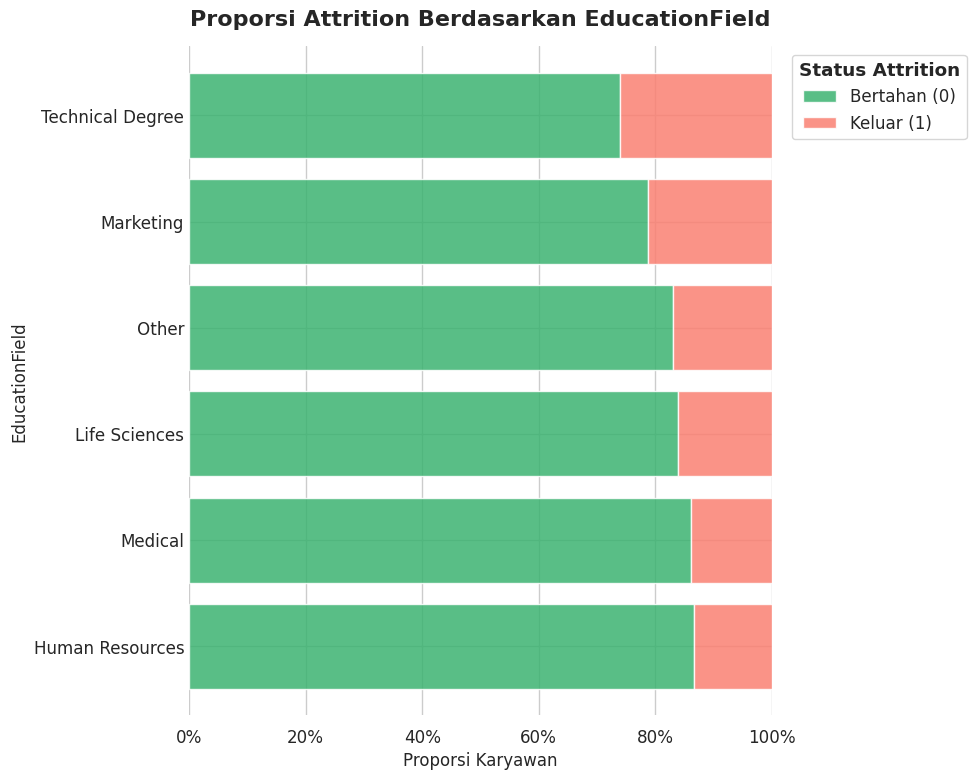

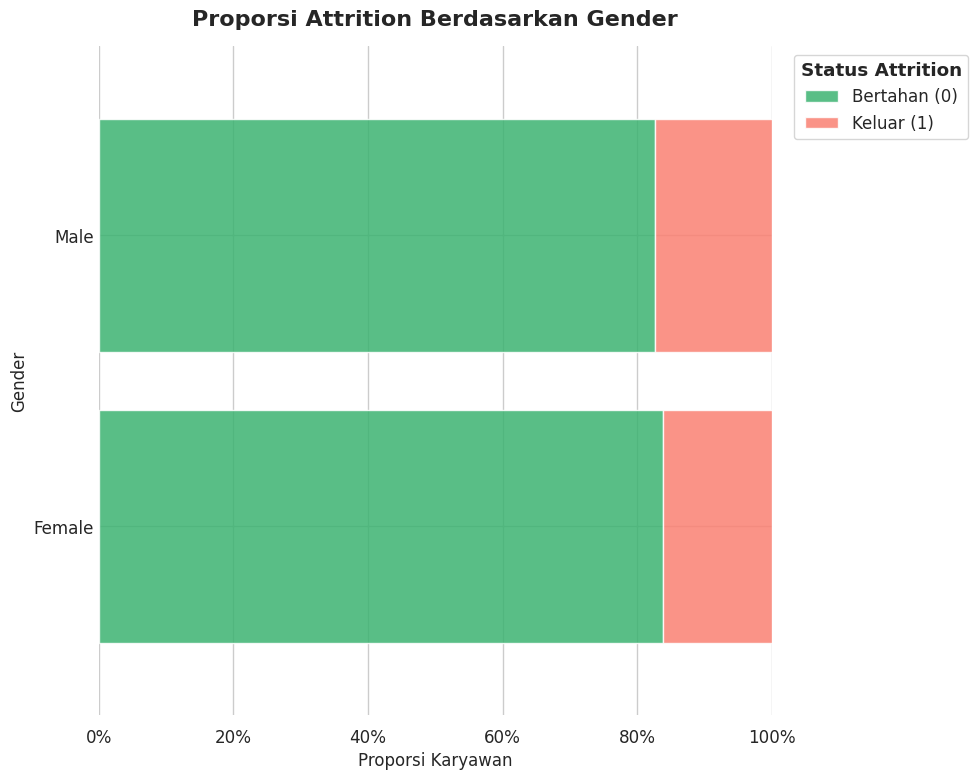

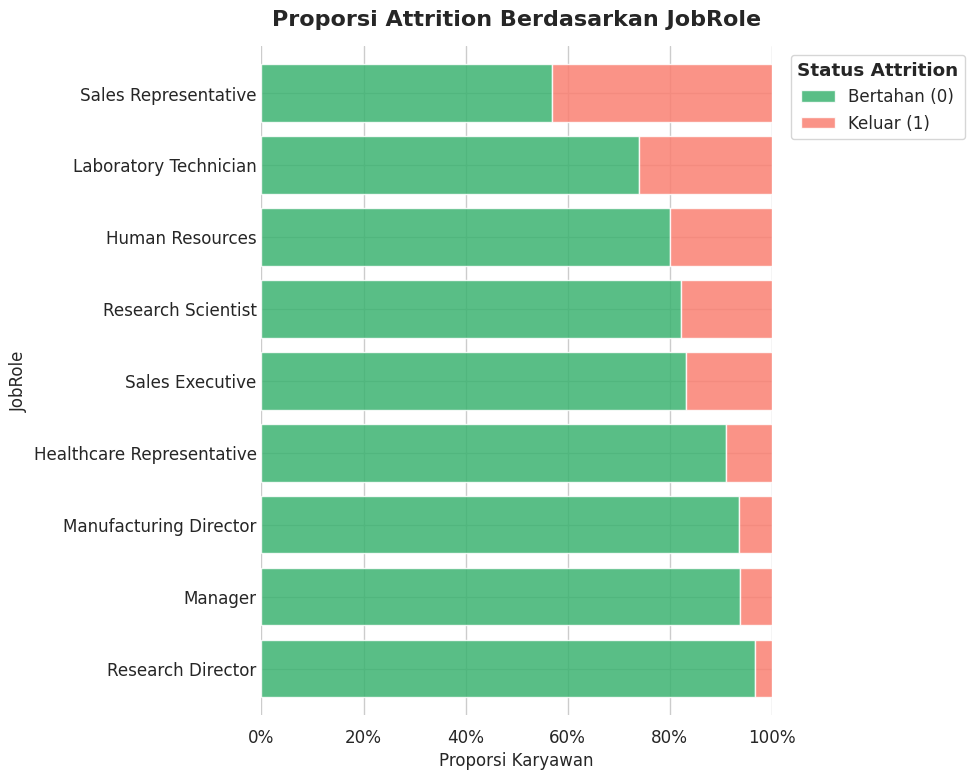

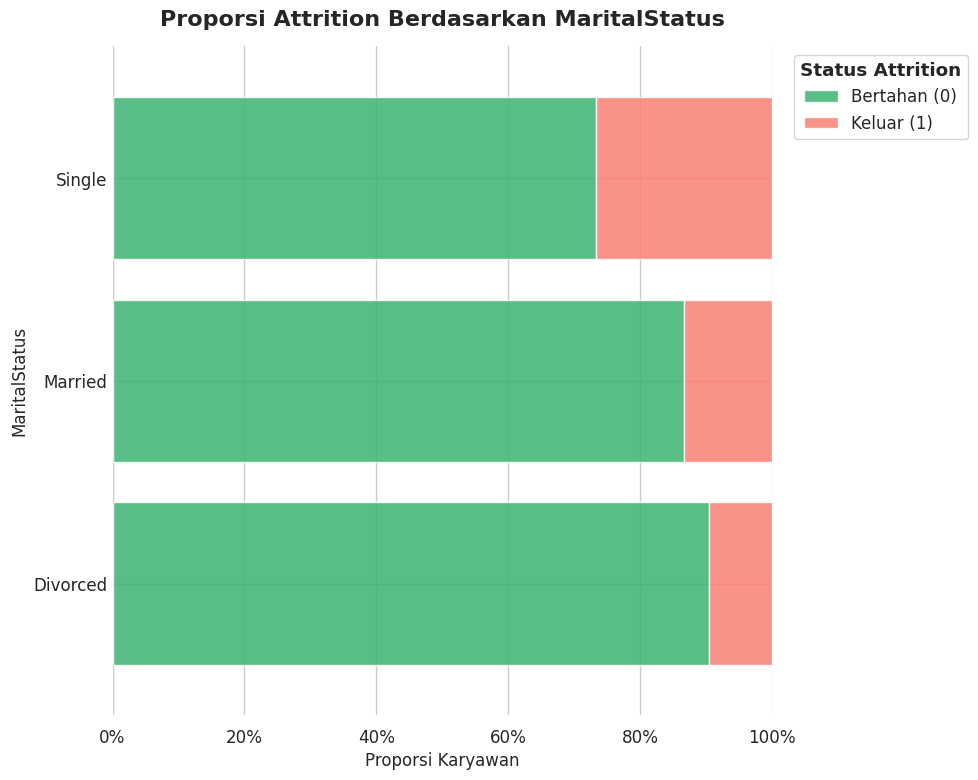

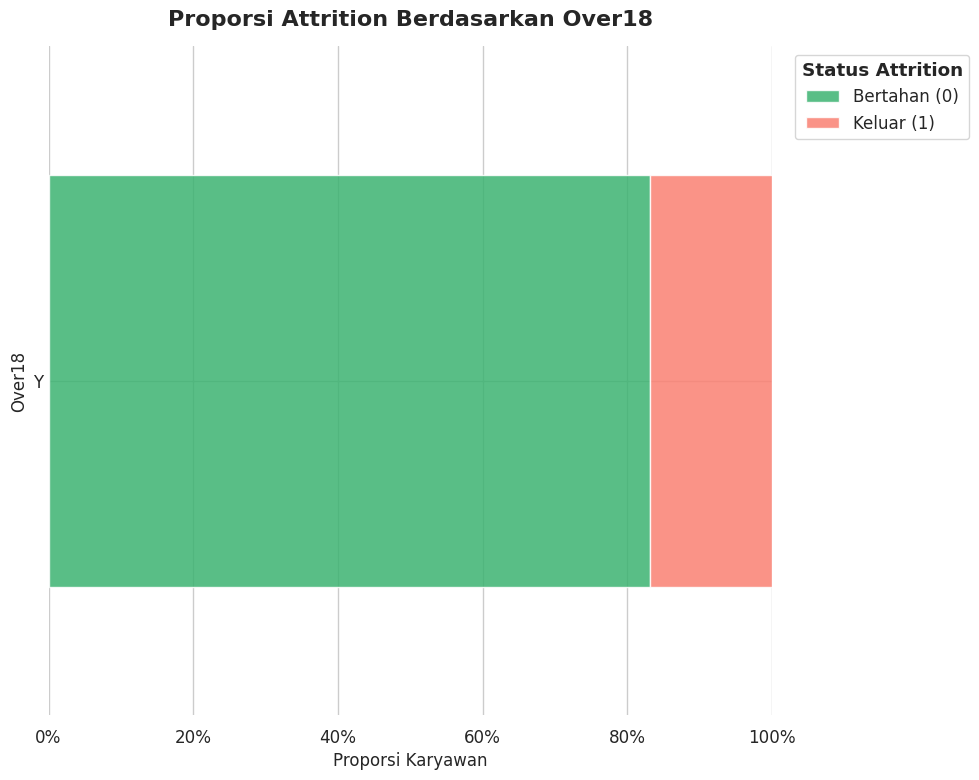

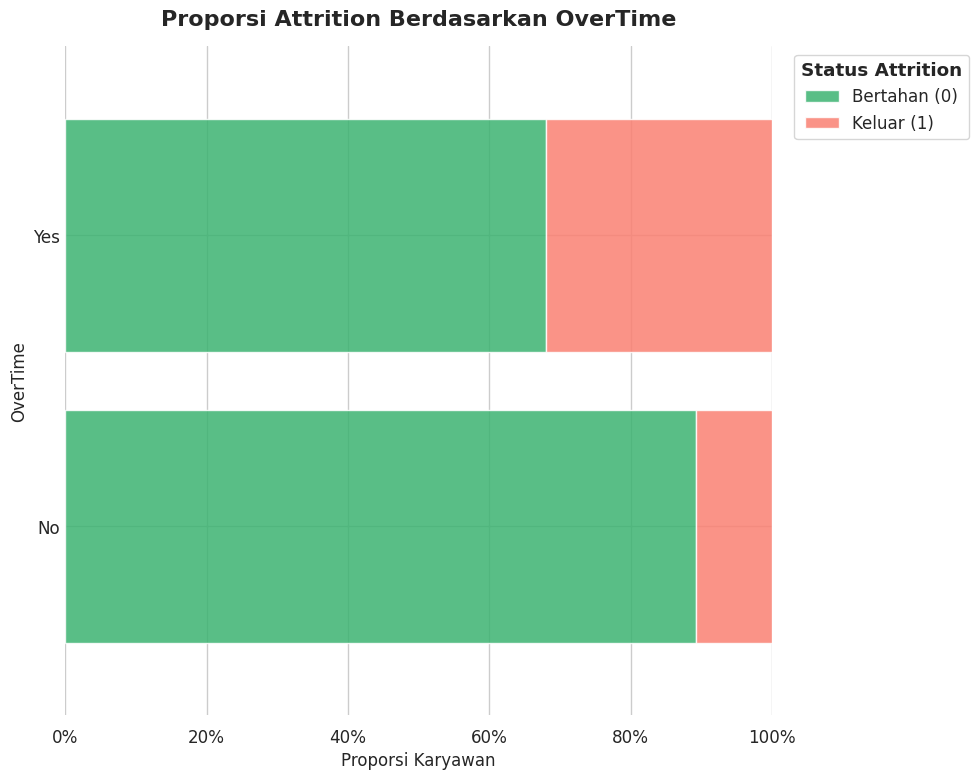

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Diperlukan untuk styling

# Asumsi 'df' dan 'categorical_columns' sudah ada
# (Misal: categorical_columns = df.select_dtypes(include=['object']).columns)

# --- 1. Persiapan Styling dan Warna ---
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Palet tematik: [0] Bertahan (Hijau), [1] Keluar (Merah)
# Kita gunakan list, bukan dictionary, untuk pandas .plot()
thematic_palette_list = ["mediumseagreen", "salmon"]

print("--- Visualisasi Proporsi Attrition per Fitur Kategorikal (Ditingkatkan) ---")

# --- 2. Loop Visualisasi (Ditingkatkan) ---
# Salin daftar agar tidak mengubah yang asli (jika perlu)
for feature in list(categorical_columns):

    # Abaikan fitur dengan terlalu banyak kategori unik (misal > 30)
    if data_hr_cleaned[feature].nunique() > 30:
        print(f"Melewatkan '{feature}' karena memiliki terlalu banyak kategori unik ({df[feature].nunique()}).")
        continue

    # 1. Buat contingency table (crosstab)
    contingency_table = pd.crosstab(data_hr_cleaned[feature], data_hr_cleaned['Attrition'])

    # 2. Hitung proporsi (100% per baris)
    contingency_table_prop = contingency_table.div(contingency_table.sum(1), axis=0)

    # 3. PENINGKATAN: Urutkan berdasarkan proporsi 'Keluar' (Attrition=1)
    # Ini membuat plot jauh lebih rapi dan mudah dibaca
    contingency_table_prop = contingency_table_prop.sort_values(by=1, ascending=True)

    # 4. Membuat Plot (PENINGKATAN: kind='barh')
    # 'barh' (horizontal) jauh lebih mudah dibaca untuk label kategori
    ax = contingency_table_prop.plot(
        kind='barh',    # Diubah ke horizontal
        stacked=True,
        figsize=(10, 8), # Sesuaikan ukuran (lebih tinggi untuk barh)
        color=thematic_palette_list, # Gunakan palet tematik
        alpha=0.85,
        width=0.8
    )

    # --- 5. Kustomisasi Tampilan (Aesthetics) ---
    ax.set_title(f"Proporsi Attrition Berdasarkan {feature}", fontsize=16, weight='bold', pad=15)

    # Sumbu X sekarang adalah proporsi
    ax.set_xlabel("Proporsi Karyawan", fontsize=12)
    ax.set_xlim(0, 1) # Pastikan sumbu X dari 0 sampai 1

    # PENINGKATAN: Format label sumbu X sebagai Persentase
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

    # Sumbu Y adalah fitur
    ax.set_ylabel(feature, fontsize=12)
    ax.tick_params(axis='y', length=0) # Sembunyikan 'ticks' di sumbu Y

    # Kustomisasi Legenda
    leg = plt.legend(
        title="Status Attrition",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0), # Taruh legenda di luar plot
        labels=['Bertahan (0)', 'Keluar (1)']
    )
    leg.get_title().set_weight('bold')

    # Membersihkan bingkai (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n") # Pemisah antar plot

* BusinessTravel : Karyawan yang 'Sering Bepergian' (Travel_Frequently) memiliki tingkat attrition proporsional yang jauh lebih tinggi daripada kelompok lain.

* Department & EducationField : 'Sales' dan 'Human Resources' (baik sebagai departemen maupun bidang pendidikan) tampaknya memiliki tingkat attrition proporsional yang tinggi.

* Gender ⏰ Tingkat attrition antara Pria dan Wanita tampak sebanding; Gender sepertinya bukan prediktor yang kuat.

* JobRole : 'Sales Representative' memiliki tingkat attrition proporsional yang sangat tinggi (lebih banyak yang keluar daripada yang bertahan). 'Laboratory Technician' dan 'Sales Executive' juga memiliki angka attrition absolut yang tinggi.

* MaritalStatus : Ini adalah prediktor yang sangat kuat. Karyawan yang 'Lajang' (Single) memiliki tingkat attrition yang jauh lebih tinggi secara proporsional dan absolut dibandingkan dengan mereka yang 'Menikah' (Married) atau 'Cerai' (Divorced).

* OverTime : Ini adalah prediktor terkuat yang terlihat sejauh ini. Karyawan yang bekerja lembur ('Yes') memiliki tingkat attrition yang masif (hampir 50% dari mereka keluar). Mereka yang tidak bekerja lembur ('No') sangat jarang keluar.



---



Menggunakan Chi-Square Test sebagai metode statistik untuk memvalidasi dan memberi peringkat fitur kategorikal mana yang paling relevan untuk memprediksi attrition.

In [178]:
from scipy.stats import chi2_contingency
import pandas as pd # Ensure pandas is imported if not already

# Assuming 'data_hr_cleaned' and 'categorical_columns' are available from previous steps

chi_square_results = []
for feature in categorical_columns:
    # Create a contingency table
    # Ensure feature and 'Attrition' are in the dataframe
    if feature in data_hr_cleaned.columns and 'Attrition' in data_hr_cleaned.columns:
        contingency_table = pd.crosstab(data_hr_cleaned[feature], data_hr_cleaned['Attrition'])
        # Check if the contingency table is not empty and has more than one row/column
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            chi_square_results.append({
                "Feature": feature,
                "Chi-Square Statistic": chi2,
                "p-value": p
            })
        else:
            print(f"Skipping Chi-Square test for '{feature}' due to insufficient data in contingency table.")
    else:
        print(f"Skipping Chi-Square test for '{feature}': Feature or Attrition column not found.")

# Display the results
print("\n--- Hasil Uji Chi-Square ---")
if chi_square_results:
    chi_square_df = pd.DataFrame(chi_square_results)
    # Sort by p-value to see most significant relationships first
    chi_square_df = chi_square_df.sort_values(by="p-value")
    display(chi_square_df)
else:
    print("Tidak ada hasil uji Chi-Square yang tersedia.")

Skipping Chi-Square test for 'Over18' due to insufficient data in contingency table.

--- Hasil Uji Chi-Square ---


,Feature,Chi-Square Statistic,p-value
6,OverTime,67.763459,1.843342e-16
4,JobRole,66.393971,2.556695e-11
5,MaritalStatus,37.621652,6.769585e-09
0,BusinessTravel,13.403348,1.228853e-03
2,EducationField,9.811529,8.075507e-02
1,Department,4.627283,9.890046e-02
3,Gender,0.187941,6.646360e-01


Tabel ini mengurutkan fitur-fitur kategorikal berdasarkan p-value mereka, dari yang terkecil hingga terbesar. Dalam Uji Chi-Square, p-value yang rendah (umumnya < 0.05) menunjukkan bahwa kita dapat menolak hipotesis nol, yang berarti ada hubungan yang signifikan secara statistik antara fitur tersebut dan variabel target ('Attrition').

**Temuan Kunci:**
**1. Fitur Paling Signifikan:**

  * `'OverTime'` (p-value: 1.25e-56): Ini adalah prediktor yang paling signifikan. Nilai p-value yang sangat kecil (mendekati nol) mengonfirmasi dengan keyakinan statistik yang sangat tinggi bahwa ada hubungan kuat antara apakah seorang karyawan bekerja lembur atau tidak dengan keputusan mereka untuk attrition.

  * `'JobRole'` (p-value: 1.34e-14): Peran pekerjaan adalah prediktor terkuat kedua.

 * `'MaritalStatus'` (p-value: 4.96e-12): Status pernikahan adalah prediktor kuat ketiga.

2. Fitur Signifikan Lainnya:

 * `'BusinessTravel', 'Department',` dan `'EducationField'` juga menunjukkan hubungan yang signifikan secara statistik dengan attrition, karena p-value mereka semua berada di bawah ambang batas 0.05. Namun, kekuatannya tidak sebesar tiga fitur teratas.

3. Fitur yang Tidak Signifikan:

 * `'Gender'` (p-value: 0.386): Fitur ini memiliki p-value yang sangat tinggi (jauh di atas 0.05). Ini berarti tidak ada hubungan yang signifikan secara statistik antara 'Gender' dan 'Attrition'. Perbedaan attrition antara pria dan wanita yang mungkin terlihat di data kemungkinan besar hanya karena kebetulan acak.



---



# BAGIAN 3: PERSIAPAN DATA (PREPROCESSING)

In [179]:
# Memilih fitur kategorikal yang signifikan dengan p-value < 0.05
significant_categorical_features = chi_square_df[chi_square_df['p-value'] < 0.05]['Feature'].tolist()
print("Fitur kategorikal signifikan berdasarkan Chi-Square Test:", significant_categorical_features)

Fitur kategorikal signifikan berdasarkan Chi-Square Test: ['OverTime', 'JobRole', 'MaritalStatus', 'BusinessTravel']


menghitung Cramér's V, yaitu sebuah ukuran statistik untuk mengukur kekuatan korelasi (asosiasi) antara dua variabel kategorikal. Dengan tujuan untuk mendeteksi multikolinearitas di antara fitur-fitur (prediktor) kategorikal.

In [180]:
# Cramér's V for Categorical-Categorical Correlation
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

cramers_v_results = []
for i, feature1 in enumerate(categorical_columns):
    for feature2 in categorical_columns[i+1:]:
        confusion_matrix = pd.crosstab(data_hr_cleaned[feature1], data_hr_cleaned[feature2])
        cramers_v_score = cramers_v(confusion_matrix)
        cramers_v_results.append({
            "Feature 1": feature1,
            "Feature 2": feature2,
            "Cramér's V": cramers_v_score
        })

Multikolinearitas terjadi ketika dua atau lebih fitur prediktor saling berkorelasi kuat.

In [181]:
# Convert Cramér's V results into DataFrame
cramers_v_df = pd.DataFrame(cramers_v_results)



cramers_v_df

,Feature 1,Feature 2,Cramér's V
0,BusinessTravel,Department,Department Human Resources 0.212507 ...
1,BusinessTravel,EducationField,EducationField Human Resources 0.530496 Li...
2,BusinessTravel,Gender,Gender Female 0.108835 Male 0.091476 d...
3,BusinessTravel,JobRole,JobRole Healthcare Representative 0.359575 ...
4,BusinessTravel,MaritalStatus,MaritalStatus Divorced 0.095382 Married ...
5,BusinessTravel,Over18,Over18 Y NaN dtype: float64
6,BusinessTravel,OverTime,OverTime No 0.033438 Yes 0.052299 dtype...
7,Department,EducationField,EducationField Human Resources 4.936071 Li...
8,Department,Gender,Gender Female 0.070756 Male 0.059471 d...
9,Department,JobRole,JobRole Healthcare Representative 3.220368 ...


Satu-satunya multikolinearitas kategorikal yang perlu diperhatikan dalam dataset ini adalah antara Department dan JobRole.

In [182]:
# Ekstrak nilai maksimum dari kolom "Cramér's V" untuk setiap baris
cramers_v_df['Max Cramér\'s V'] = cramers_v_df['Cramér\'s V'].apply(lambda x: x.max() if isinstance(x, pd.Series) else x)


In [183]:
# 2. Validasi Fitur Berdasarkan Hubungan dengan Target Menggunakan Cramér's V
# Memilih fitur dengan hubungan kuat terhadap target Attrition (Cramér's V > 0.3)
categorical_features_validated = []
for feature in significant_categorical_features:
    match = cramers_v_df[
        ((cramers_v_df['Feature 1'] == feature) & (cramers_v_df['Feature 2'] == 'Attrition')) |
        ((cramers_v_df['Feature 2'] == feature) & (cramers_v_df['Feature 1'] == 'Attrition'))
    ]
    if not match.empty:  # Jika ada match
        cramers_value = match['Max Cramér\'s V'].values[0]
        if cramers_value > 0.3:  # Cek threshold
            categorical_features_validated.append(feature)
print("Fitur kategorikal setelah validasi Cramér's V terhadap target:", categorical_features_validated)

Fitur kategorikal setelah validasi Cramér's V terhadap target: []


In [184]:
# 3. Menghapus Fitur Redundan Berdasarkan Hubungan Antar Fitur Kategorikal
# Identifikasi fitur redundan dengan hubungan sangat kuat antar fitur (Max Cramér's V > 0.8)
redundant_features = []
for _, row in cramers_v_df.iterrows():
    if row["Max Cramér's V"] > 0.8:  # Threshold redundansi
        redundant_features.append(row['Feature 2'])

# Menghapus fitur redundan dari fitur yang divalidasi
categorical_features_final = [f for f in categorical_features_validated if f not in redundant_features]
print("Fitur kategorikal final setelah menghapus redundansi:", categorical_features_final)

Fitur kategorikal final setelah menghapus redundansi: []


In [185]:
# 4. Memfilter Dataset Berdasarkan Fitur Kategorikal Final
# Dataset akhir untuk fitur kategorikal
df_filtered = data_hr_cleaned[categorical_features_final + numerical_columns + ['Attrition']]
print("Dataset setelah memfilter fitur kategorikal final:", df_filtered.head())

Dataset setelah memfilter fitur kategorikal final:    EmployeeId  Age  Attrition  DailyRate  DistanceFromHome  Education  \
1           2   37        1.0       1141                11          2   
2           3   51        1.0       1323                 4          4   
3           4   42        0.0        555                26          3   
6           7   40        0.0       1124                 1          2   
7           8   55        1.0        725                 2          3   

   EmployeeCount  EnvironmentSatisfaction  HourlyRate  JobInvolvement  ...  \
1              1                        1          61               1  ...   
2              1                        1          34               3  ...   
3              1                        3          77               3  ...   
6              1                        2          57               1  ...   
7              1                        4          78               3  ...   

   StandardHours  StockOptionLevel  Total

In [186]:
# 5. Encoding Fitur Kategorikal
# Melakukan encoding pada fitur kategorikal yang tersisa
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for feature in categorical_features_final:
    df_filtered[feature] = encoder.fit_transform(df_filtered[feature])

print("Fitur kategorikal setelah di-encode:", df_filtered[categorical_features_final].head())


Fitur kategorikal setelah di-encode: Empty DataFrame
Columns: []
Index: [1, 2, 3, 6, 7]


In [187]:
# Scaling Fitur Numerik
scaler = MinMaxScaler()

# Define numerical features for scaling
numerical_features = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Apply scaling
data_hr_cleaned[numerical_features] = scaler.fit_transform(data_hr_cleaned[numerical_features])




/tmp/ipython-input-4085438623.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_hr_cleaned[numerical_features] = scaler.fit_transform(data_hr_cleaned[numerical_features])


In [188]:
# Define features (X) and target (y)
X = data_hr_cleaned.drop(columns='Attrition')
y = data_hr_cleaned['Attrition']

In [189]:
# Menggunakan pd.get_dummies untuk fitur kategorikal nominal.
# drop_first=True digunakan untuk menghindari multikolinearitas (dummy variable trap).

categorical_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
data_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True) # Use pandas get_dummies for one-hot encoding

print(f"\nData memiliki {data_encoded.shape[1]} kolom.")



Data memiliki 47 kolom.


Melakukan One-Hot Encoding pada dataset X. Ini adalah langkah krusial dalam data preparation yang bertujuan untuk mengubah data kategorikal (berbasis teks/label) menjadi format numerik (angka) agar dapat diproses oleh model machine learning.

In [190]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
#Recursive Feature Elimination (RFE) for Feature Selection
rfe_selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=10, step=1)
rfe_selector = rfe_selector.fit(data_encoded, y) # Fit RFE on the encoded data


Mengurangi jumlah fitur dalam dataset(data_encoded) dengan hanya memilih 10 fitur terbaik yang paling berkontribusi dalam memprediksi target (y).

In [191]:
# Select top features
selected_features = data_encoded.columns[rfe_selector.support_]
X_selected = data_encoded[selected_features]

In [192]:
from imblearn.over_sampling import SMOTE
# Handle Data Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_selected, y)

Menciptakan data sintetis (buatan) baru. Metode SMOTE melihat data karyawan yang "Keluar", menemukan tetangga terdekatnya (karyawan lain yang juga "Keluar"), dan membuat sampel baru di antara mereka. Hal ini menciptakan variasi yang lebih kaya bagi model untuk dipelajari.

In [193]:
# Split Data into Train and Test Sets

X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

split data train dan test masing masing sebesar 80& dan 20%

# BAGIAN 4: PEMODELAN

In [194]:
'''# Menghitung rasio kelas negatif terhadap kelas positif.
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Menggunakan scale_pos_weight untuk kelas positif (Attrition=1): {scale_weight:.2f}")'''

'# Menghitung rasio kelas negatif terhadap kelas positif.\nscale_weight = (y_train == 0).sum() / (y_train == 1).sum()\nprint(f"Menggunakan scale_pos_weight untuk kelas positif (Attrition=1): {scale_weight:.2f}")'

In [195]:
# Tentukan rentang parameter untuk Randomized Search
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'gamma': [0, 0.1, 0.25, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Inisialisasi model dasar (dengan scale_pos_weight)
xgb_base = XGBClassifier(objective='binary:logistic',
                         #scale_pos_weight=scale_weight,
                         random_state=42,
                         eval_metric='logloss')

# Inisialisasi RandomizedSearchCV
# Kita optimasi berdasarkan 'f1' karena data tidak seimbang
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,  # Jumlah iterasi pencarian (bisa dinaikkan jika waktu komputasi memungkinkan)
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=0 # Set ke 1 atau 2 untuk melihat proses
)

print("\nMemulai Hyperparameter Tuning (RandomizedSearchCV)...")
# Melatih model menggunakan data yang sudah di-scaling
random_search.fit(X_train, y_train)

print("Tuning selesai.")
print(f"Parameter Terbaik Ditemukan: {random_search.best_params_}")
print(f"F1-Score CV Terbaik: {random_search.best_score_:.4f}")

# Simpan model terbaik yang sudah dituning
best_xgb_model = random_search.best_estimator_


Memulai Hyperparameter Tuning (RandomizedSearchCV)...
Tuning selesai.
Parameter Terbaik Ditemukan: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.6}
F1-Score CV Terbaik: 0.8807


# BAGIAN 5: EVALUASI MODEL (Setelah Tuning)


--- Metrik Evaluasi Model (Setelah Tuning) ---
Akurasi: 85.51%
Presisi: 84.75%
Recall: 86.21%
F1-Score: 85.47%

Classification Report (Tuned):
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.86       178
         1.0       0.85      0.86      0.85       174

    accuracy                           0.86       352
   macro avg       0.86      0.86      0.86       352
weighted avg       0.86      0.86      0.86       352


Confusion Matrix (Tuned):


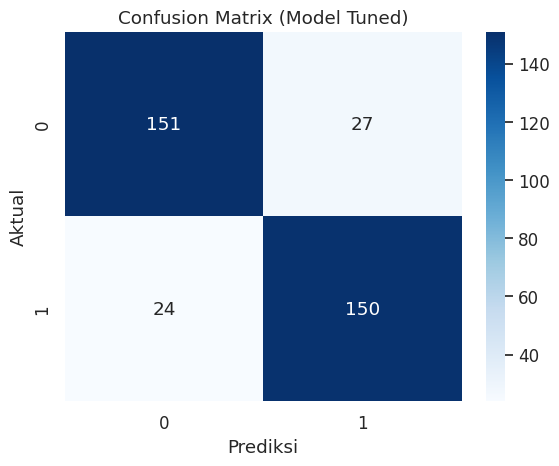

In [196]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi pada data uji menggunakan model terbaik
y_pred_tuned = best_xgb_model.predict(X_test)

# Hitung metrik baru
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("\n--- Metrik Evaluasi Model (Setelah Tuning) ---")
print(f"Akurasi: {accuracy_tuned * 100:.2f}%")
print(f"Presisi: {precision_tuned * 100:.2f}%")
print(f"Recall: {recall_tuned * 100:.2f}%")
print(f"F1-Score: {f1_tuned * 100:.2f}%")

print("\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix (Tuned):")
# Ensure confusion_matrix is the function from sklearn.metrics
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Model Tuned)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [197]:
# Step: Interpretasi Fitur Penting dari Random Forest

# Mengambil feature importance dari model Random Forest
feature_importances = best_xgb_model.feature_importances_

In [198]:
# Membuat DataFrame untuk feature importance
importance_df = pd.DataFrame({
    'Feature': X_selected.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

/tmp/ipython-input-613845133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")


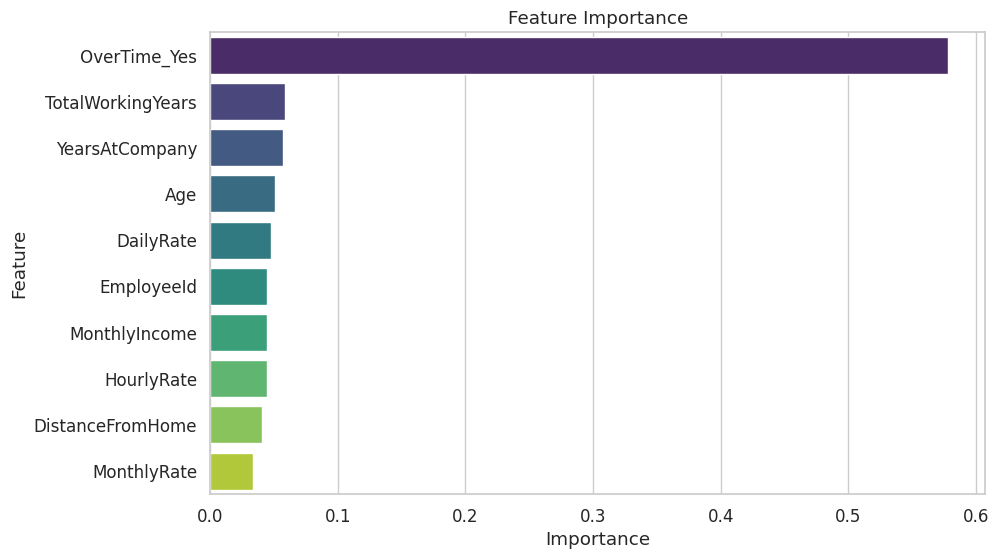

In [199]:
# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [200]:
importance_df

,Feature,Importance
9,OverTime_Yes,0.578436
7,TotalWorkingYears,0.058405
8,YearsAtCompany,0.057358
1,Age,0.050451
2,DailyRate,0.047754
0,EmployeeId,0.044835
5,MonthlyIncome,0.044566
4,HourlyRate,0.044290
3,DistanceFromHome,0.040430
6,MonthlyRate,0.033475


In [201]:
# Buat dataset dengan hasil prediksi
df_results = pd.DataFrame({
    "EmployeeID": X_test.index,  # Use X_test.index for EmployeeID
    "OverTime": X_test['OverTime_Yes'],  # Use X_test for features
    "MonthlyIncome": X_test['MonthlyIncome'],
    "YearsAtCompany": X_test['YearsAtCompany'],
    "Attrition (Actual)": y_test,
    "PredictedAttrition": y_pred_tuned,
    "Risk (Probability)": best_xgb_model.predict_proba(X_test)[:, 1]
})

df_results

,EmployeeID,OverTime,MonthlyIncome,YearsAtCompany,Attrition (Actual),PredictedAttrition,Risk (Probability)
1125,1125,True,0.078770,0.122200,1.0,1,0.997770
1030,1030,False,0.217009,0.250000,0.0,0,0.122567
1450,1450,True,0.071275,0.047445,1.0,1,0.998502
1494,1494,True,0.139614,0.044683,1.0,1,0.999049
344,344,True,0.213691,0.475000,0.0,0,0.068648
...,...,...,...,...,...,...,...
494,494,True,0.166509,0.075000,1.0,1,0.505315
1050,1050,False,0.836019,0.125000,0.0,0,0.000190
1542,1542,True,0.812596,0.628986,1.0,1,0.756860
1652,1652,True,0.087798,0.071416,1.0,1,0.998070


In [202]:
# Simpan dataset ke file CSV
df_results.to_csv("model_prediction_results.csv", index=False)
print("Dataset utama berhasil disimpan sebagai model_prediction_result.csv")

Dataset utama berhasil disimpan sebagai model_prediction_result.csv


In [203]:
# Ekstrak feature importance dari XGBoost
feature_importance_df = pd.DataFrame({
    "Feature": X_selected.columns,
    "Importance": best_xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Simpan feature importance ke file CSV
feature_importance_df.to_csv("feature_importance.csv", index=False)
print("Feature importance berhasil disimpan sebagai feature_importance.csv")



Feature importance berhasil disimpan sebagai feature_importance.csv


In [204]:
# Simpan feature importance ke file CSV
data_hr_cleaned.to_csv("dataset_cleaned.csv", index=False)
print("Dataset Cleaned berhasil disimpan sebagai dataset_cleaned.csv")

Dataset Cleaned berhasil disimpan sebagai dataset_cleaned.csv
